# **ENVIROMENT INITIALIZATION**

In [1]:
# IMPORTS
# Math libraries
import numpy as np
from scipy import stats
import pandas as pd
import polars as pl

# Plots
import matplotlib.pyplot as plt

# Technical libraries
from datetime import date

In [2]:
# CONFIGURATION
from config import (
    PROJECT_ROOT,
    AS_OF, TARGET_START, TARGET_END,
    DATA_RAW_DIR, DATA_PROCESSED_DIR, DATA_FEATURES_DIR,
    TRAIN_PATH, CV_TARGET_PATH, HISTORY_PATH, CV_FEATURES_PATH,
    REPORTS_DIR, REPORTS_GMV_DIR, REPORTS_CONV_FUNL_DIR, REPORTS_FEATURES_DIR,
    WINDOWS,
    GMV_COLS, ACTIVITY_COLS, CONVERSION_COLS,
    BIN_ORDER,
    create_directories,
    validate_data_exists,
)

# Creating directories
create_directories()

# Checking for data availability
validate_data_exists()

# Configuration info
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"TRAIN_PATH: {TRAIN_PATH}")
print(f"CV_TARGET_PATH: {CV_TARGET_PATH}")
print(f"REPORTS_GMV_DIR: {REPORTS_GMV_DIR}")
print(f"AS_OF: {AS_OF}")
print(f"REPORTS_CONV_FUNL_DIR: {REPORTS_CONV_FUNL_DIR}")
print(f"BIN_ORDER: {BIN_ORDER}")

All directories created successfully.
TRAIN_PATH: 171.80 MB
CV_TARGET_PATH: 1.32 MB

All data files are present.
PROJECT_ROOT: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech
TRAIN_PATH: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\data\raw\train.parquet
CV_TARGET_PATH: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\data\processed\cv_target_2026-01-14.parquet
REPORTS_GMV_DIR: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\gmv
AS_OF: 2026-01-14
REPORTS_CONV_FUNL_DIR: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\conv_funl
BIN_ORDER: ['0-1%', '1-5%', '5-10%', '10-20%', '20-50%', '50-100%']


In [3]:
# DATA LOADING
cv_target_lf = pl.scan_parquet(CV_TARGET_PATH)
cv_target = pl.read_parquet(CV_TARGET_PATH)

train_lf = pl.scan_parquet(TRAIN_PATH)
train = pl.read_parquet(TRAIN_PATH)
print(f"Train data loaded: {train_lf.collect_schema()}")

Train data loaded: Schema({'event_date': Date, 'user_id': Int64, 'search': Int64, 'cat': Int64, 'has_search_to_cart': Int64, 'has_search_to_ord': Int64, 'has_cat_to_cart': Int64, 'has_cat_to_ord': Int64, 'search_to_cart': Int64, 'search_to_ord': Int64, 'cat_to_cart': Int64, 'cat_to_ord': Int64, 'gmv_search': Float64, 'gmv_cat': Float64, 'to_cart': Int64, 'to_ord': Int64, 'gmv': Float64, 'searches': Int64})


## **CUSTOM FUNCTIONS**

In [4]:
# FUNCTION FOR CONVERTING POLAR TABLES IN EDA
def print_vertical_one_row(df: pl.DataFrame) -> None:
    """
    It conveniently prints wide tables with a single line.
    If there are more lines, it prints a table with expanded output.
    """
    if df.height == 0:
        print("Empty DataFrame")
        return

    if df.height == 1:
        row = df.row(0)
        for col_name, value in zip(df.columns, row):
            print(f"{col_name:45} {value}")
    else:
        with pl.Config() as cfg:
            cfg.set_tbl_cols(-1)
            cfg.set_tbl_width_chars(-1)
            cfg.set_tbl_rows(-1)
            print(df)

# **EXPLORATORY DATA ANALISYS - DATA AUDIT**

### **ABOUT DATASET:**
- **event_date** – дата с 2025-01-01 по 2026-02-13
- **user_id** — идентификатор пользователя
- **search** – флаг пользования Поиском (0 или 1)
- **cat** – флаг пользования Каталогом (0 или 1)
- **has_search_to_cart** – флаг переноса товара в корзину при пользовании Поиском (0 или 1)
- **has_search_to_ord** – флаг покупки товара при пользовании Поиском (0 или 1)
- **has_cat_to_cart** – флаг переноса товара в корзину при пользовании Каталогом (0 или 1)
- **has_cat_to_ord** – флаг покупки товара при пользовании Каталогом (0 или 1)
- **search_to_cart** – число добавленных в корзину товаров при пользовании Поиском
- **search_to_ord** – число купленных товаров при пользовании Поиском 
- **cat_to_cart** – число добавленных в корзину товаров при пользовании Каталогом
- **cat_to_ord** – число купленных товаров при пользовании Каталогом 
- **gmv_search** – суммарная стоимость купленных товаров при пользовании Поиском
- **gmv_cat** – суммарная стоимость купленных товаров при пользовании Каталогом
- **to_cart** – суммарное число добавленных в корзину товаров
- **to_ord** – суммарное число купленных товаров
- **gmv** – суммарная стоимость купленных товаров
- **searches** – суммарное число поисковых запросов

In [5]:
# FORMAT CHECKING
schema = train_lf.collect_schema()

for col_name, col_type in schema.items():
    print(f"{col_name:20} {col_type}")

event_date           Date
user_id              Int64
search               Int64
cat                  Int64
has_search_to_cart   Int64
has_search_to_ord    Int64
has_cat_to_cart      Int64
has_cat_to_ord       Int64
search_to_cart       Int64
search_to_ord        Int64
cat_to_cart          Int64
cat_to_ord           Int64
gmv_search           Float64
gmv_cat              Float64
to_cart              Int64
to_ord               Int64
gmv                  Float64
searches             Int64


In [6]:
# GLIMPSE SOME OBSERVATIONS
train_lf.head(20).collect()

event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,i64
2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-01,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,5
2026-02-06,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2026-02-11,2,1,0,1,0,0,0,2,0,0,0,0.0,0.0,2,0,0.0,1


In [7]:
# GETTING A NUMBER OF OBSERVATIONS
train_lf.select(pl.len()).collect()

len
u32
30631006


In [8]:
# OBSERVATIONS INFO
USER_COL = "user_id"

n_users = train_lf.select(pl.col(USER_COL).n_unique()).collect().item()
print("Unique users:", n_users)

# TIME COLUMN INFO
DATE_COL = "event_date"

date_stats = train_lf.select(
    pl.col(DATE_COL).min().alias("min_date"),
    pl.col(DATE_COL).max().alias("max_date")
).collect()

print(date_stats)

# GMV INFO
REVENUE_COL = "gmv"

revenue_stats = train_lf.select(
    pl.col(REVENUE_COL).min().alias("min"), 
    pl.col(REVENUE_COL).mean().alias("mean"),
    pl.col(REVENUE_COL).median().alias("median"),
    pl.col(REVENUE_COL).max().alias("max"),
    pl.col(REVENUE_COL).sum().alias("total"),

    (pl.col(REVENUE_COL) > 0).mean().alias("share_positive")
).collect()

print(revenue_stats)

Unique users: 250000
shape: (1, 2)
┌────────────┬────────────┐
│ min_date   ┆ max_date   │
│ ---        ┆ ---        │
│ date       ┆ date       │
╞════════════╪════════════╡
│ 2025-01-01 ┆ 2026-02-13 │
└────────────┴────────────┘
shape: (1, 6)
┌─────┬──────────┬────────┬──────────────┬──────────┬────────────────┐
│ min ┆ mean     ┆ median ┆ max          ┆ total    ┆ share_positive │
│ --- ┆ ---      ┆ ---    ┆ ---          ┆ ---      ┆ ---            │
│ f64 ┆ f64      ┆ f64    ┆ f64          ┆ f64      ┆ f64            │
╞═════╪══════════╪════════╪══════════════╪══════════╪════════════════╡
│ 0.0 ┆ 8.883207 ┆ 0.0    ┆ 73830.297037 ┆ 2.7210e8 ┆ 0.154644       │
└─────┴──────────┴────────┴──────────────┴──────────┴────────────────┘


## **CHECKING FOR MISSINGS, DUBLICATES ETC.**

In [9]:
# SEARCHING FOR NULLS IN DATA
null_counts = train_lf.select(pl.all().null_count()).collect()
print_vertical_one_row(null_counts)

event_date                                    0
user_id                                       0
search                                        0
cat                                           0
has_search_to_cart                            0
has_search_to_ord                             0
has_cat_to_cart                               0
has_cat_to_ord                                0
search_to_cart                                0
search_to_ord                                 0
cat_to_cart                                   0
cat_to_ord                                    0
gmv_search                                    0
gmv_cat                                       0
to_cart                                       0
to_ord                                        0
gmv                                           0
searches                                      0


In [10]:
# CHECKING IF NaN IN FLOAT COLUMNS
float_cols = [
    col for col, dtype in schema.items()
    if dtype == pl.Float64]

print("Float columns:", float_cols)

if float_cols:
    nan_counts = train_lf.select(
        [pl.col(c).is_nan().sum().alias(c) for c in float_cols]
    ).collect()
    print(nan_counts)

Float columns: ['gmv_search', 'gmv_cat', 'gmv']
shape: (1, 3)
┌────────────┬─────────┬─────┐
│ gmv_search ┆ gmv_cat ┆ gmv │
│ ---        ┆ ---     ┆ --- │
│ u32        ┆ u32     ┆ u32 │
╞════════════╪═════════╪═════╡
│ 0          ┆ 0       ┆ 0   │
└────────────┴─────────┴─────┘


In [11]:
# CHECKING IF DUBLICATES IN USERS BY A DAY
# If dublicates in -> must be combined
duplicates = (
    train_lf.group_by(["user_id", "event_date"])
      .len()
      .filter(pl.col("len") > 1)
)

print(duplicates.collect())

shape: (0, 3)
┌─────────┬────────────┬─────┐
│ user_id ┆ event_date ┆ len │
│ ---     ┆ ---        ┆ --- │
│ i64     ┆ date       ┆ u32 │
╞═════════╪════════════╪═════╡
└─────────┴────────────┴─────┘


In [12]:
# CHECKING GMV FOR MISMATCHES
gmv_check = train_lf.select(
    pl.len().alias("rows"),
    pl.col("gmv").is_null().sum().alias("gmv_nulls"),
    pl.col("gmv_search").is_null().sum().alias("gmv_search_nulls"),
    pl.col("gmv_cat").is_null().sum().alias("gmv_cat_nulls"),
    (pl.col("gmv") < 0).sum().alias("gmv_negative"),
    (pl.col("gmv_search") < 0).sum().alias("gmv_search_negative"),
    (pl.col("gmv_cat") < 0).sum().alias("gmv_cat_negative"),
    (
        (
            pl.col("gmv").fill_null(0.0)
            - (
                pl.col("gmv_search").fill_null(0.0)
                + pl.col("gmv_cat").fill_null(0.0)
            )
        ).abs() > 1e-6
    ).sum().alias("gmv_not_equal_sum")
).collect()

print(gmv_check)

shape: (1, 8)
┌──────────┬───────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ rows     ┆ gmv_nulls ┆ gmv_search ┆ gmv_cat_nu ┆ gmv_negati ┆ gmv_search ┆ gmv_cat_n ┆ gmv_not_e │
│ ---      ┆ ---       ┆ _nulls     ┆ lls        ┆ ve         ┆ _negative  ┆ egative   ┆ qual_sum  │
│ u32      ┆ u32       ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│          ┆           ┆ u32        ┆ u32        ┆ u32        ┆ u32        ┆ u32       ┆ u32       │
╞══════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 30631006 ┆ 0         ┆ 0          ┆ 0          ┆ 0          ┆ 0          ┆ 0         ┆ 0         │
└──────────┴───────────┴────────────┴────────────┴────────────┴────────────┴───────────┴───────────┘


In [13]:
# CHECKING IF TROUBLES IN BINARY COLUMNS
binary_cols = [
    "search",
    "cat",
    "has_search_to_cart",
    "has_search_to_ord",
    "has_cat_to_cart",
    "has_cat_to_ord",
]

binary_exprs = []

for c in binary_cols:
    binary_exprs.extend([
        pl.col(c).min().alias(f"{c}_min"),
        pl.col(c).max().alias(f"{c}_max"),
        pl.col(c).n_unique().alias(f"{c}_uniq"),
        ((pl.col(c) != 0) & (pl.col(c) != 1)).sum().alias(f"{c}_not_0_1"),
    ])

binary_stats = train_lf.select(binary_exprs).collect()

print_vertical_one_row(binary_stats)

search_min                                    0
search_max                                    1
search_uniq                                   2
search_not_0_1                                0
cat_min                                       0
cat_max                                       1
cat_uniq                                      2
cat_not_0_1                                   0
has_search_to_cart_min                        0
has_search_to_cart_max                        1
has_search_to_cart_uniq                       2
has_search_to_cart_not_0_1                    0
has_search_to_ord_min                         0
has_search_to_ord_max                         1
has_search_to_ord_uniq                        2
has_search_to_ord_not_0_1                     0
has_cat_to_cart_min                           0
has_cat_to_cart_max                           1
has_cat_to_cart_uniq                          2
has_cat_to_cart_not_0_1                       0
has_cat_to_ord_min                      

In [14]:
# CHECKING OTHER COLUMNS
count_cols = [
    "search_to_cart",
    "search_to_ord",
    "cat_to_cart",
    "cat_to_ord",
    "to_cart",
    "to_ord",
    "searches",
]

count_exprs = []

for c in count_cols:
    count_exprs.extend([
        pl.col(c).min().alias(f"{c}_min"),
        pl.col(c).max().alias(f"{c}_max"),
        pl.col(c).median().alias(f"{c}_median"),
        pl.col(c).n_unique().alias(f"{c}_uniq"),
        (pl.col(c) < 0).sum().alias(f"{c}_negative"),
    ])

count_stats = train_lf.select(count_exprs).collect()

print_vertical_one_row(count_stats)

search_to_cart_min                            0
search_to_cart_max                            816
search_to_cart_median                         0.0
search_to_cart_uniq                           240
search_to_cart_negative                       0
search_to_ord_min                             0
search_to_ord_max                             138
search_to_ord_median                          0.0
search_to_ord_uniq                            74
search_to_ord_negative                        0
cat_to_cart_min                               0
cat_to_cart_max                               1535
cat_to_cart_median                            0.0
cat_to_cart_uniq                              158
cat_to_cart_negative                          0
cat_to_ord_min                                0
cat_to_ord_max                                68
cat_to_ord_median                             0.0
cat_to_ord_uniq                               41
cat_to_ord_negative                           0
to_cart_min       

### **Conclusion:**
- We have no nulls in data
- We have no NaN in float columns
- We have no dublicates in users grouped by day
- `gmv` = `gmv_search` + `gmv_cat`

*Data is well prepared for working*

## **CHECKING LOCAL (CV) TARGET**
*The Case implies time series split method for validation, so we have to check for cold-start users or other anomalies*

In [15]:
# CHECKING USERS BEFOR AS_OF TIMEPOS FOR DETECTION COLD-START ANOMALIES
# If hist_users is significantly smaller than all_users, it means there are cold‑start users without any history prior to date
hist_users = (
    train_lf.filter(pl.col("event_date") <= AS_OF)
      .select(pl.col("user_id").n_unique())
      .collect()
      .item()
)

all_users = (
    train_lf.select(pl.col("user_id").n_unique())
      .collect()
      .item()
)

print("Users with history before cutoff:", hist_users)
print("All users:", all_users)

Users with history before cutoff: 250000
All users: 250000


In [16]:
# CHECKING THE DISTRIBUTION OF LOCAL TARGET
target_stats = (
    cv_target_lf
    .select(
        pl.len().alias("users"),
        pl.col("target").mean().alias("mean"),
        pl.col("target").median().alias("median"),
        pl.col("target").max().alias("max"),
        (pl.col("target") == 0).mean().alias("zero_share"),
        (pl.col("target") > 0).mean().alias("positive_share"),
        pl.col("target").quantile(0.50).alias("q50"),
        pl.col("target").quantile(0.90).alias("q90"),
        pl.col("target").quantile(0.99).alias("q99"),
        pl.col("target").quantile(0.999).alias("q999"),
    )
    .collect()
)

print_vertical_one_row(target_stats)

users                                         250000
mean                                          84.03404163321817
median                                        7.892407667220075
max                                           53746.95081219209
zero_share                                    0.45934
positive_share                                0.54066
q50                                           7.89315777057838
q90                                           215.86061923975788
q99                                           1040.1368388909743
q999                                          2933.555568355758


### **Conclusion:**
- Data time split went successfully.

### **Some thoughts:**
- Gotta look at the target destribution since the mean is significantly higher compared to the median;
- Need to use log1p(gmv) transformation;
- Cannot simply remove “outliers” thoughtlessly, need to look at the top users separately later for detection of special patterns;
- Cannot use only 0 or only 1 predicting baseline for everyone because 54% of users have a positive target.

## **01 - GMV ANALISYS**

In [17]:
# COLLECTING WEEKLY GMV AMOUNTS
weekly = (
    train_lf.with_columns(
        pl.col("event_date").dt.truncate("1w").alias("week")
    )
    .group_by("week")
    .agg(
        pl.col("event_date").n_unique().alias("days_in_week"),
        pl.col("gmv").sum().alias("gmv_sum"),
        pl.col("gmv_search").sum().alias("gmv_search_sum"),
        pl.col("gmv_cat").sum().alias("gmv_cat_sum"),
        pl.col("to_ord").sum().alias("orders_sum"),
        pl.col("user_id").n_unique().alias("active_users"),
    )
    .sort("week")
    .collect()
)

# 1st and last weeks may be incomplete. We take only full weeks for the schedules
weekly_full = weekly.filter(pl.col("days_in_week") == 7)

print(weekly_full.head(10))
print(weekly_full.tail(10))

shape: (10, 7)
┌────────────┬──────────────┬──────────┬───────────────┬───────────────┬────────────┬──────────────┐
│ week       ┆ days_in_week ┆ gmv_sum  ┆ gmv_search_su ┆ gmv_cat_sum   ┆ orders_sum ┆ active_users │
│ ---        ┆ ---          ┆ ---      ┆ m             ┆ ---           ┆ ---        ┆ ---          │
│ date       ┆ u32          ┆ f64      ┆ ---           ┆ f64           ┆ i64        ┆ u32          │
│            ┆              ┆          ┆ f64           ┆               ┆            ┆              │
╞════════════╪══════════════╪══════════╪═══════════════╪═══════════════╪════════════╪══════════════╡
│ 2025-01-06 ┆ 7            ┆ 3.3868e6 ┆ 3.0826e6      ┆ 304197.189807 ┆ 94240      ┆ 141551       │
│ 2025-01-13 ┆ 7            ┆ 3.3860e6 ┆ 3.0789e6      ┆ 307112.832088 ┆ 93756      ┆ 141903       │
│ 2025-01-20 ┆ 7            ┆ 3.2687e6 ┆ 2.9813e6      ┆ 287440.9936   ┆ 92623      ┆ 142298       │
│ 2025-01-27 ┆ 7            ┆ 3.2119e6 ┆ 2.9126e6      ┆ 299269.450008 ┆ 892

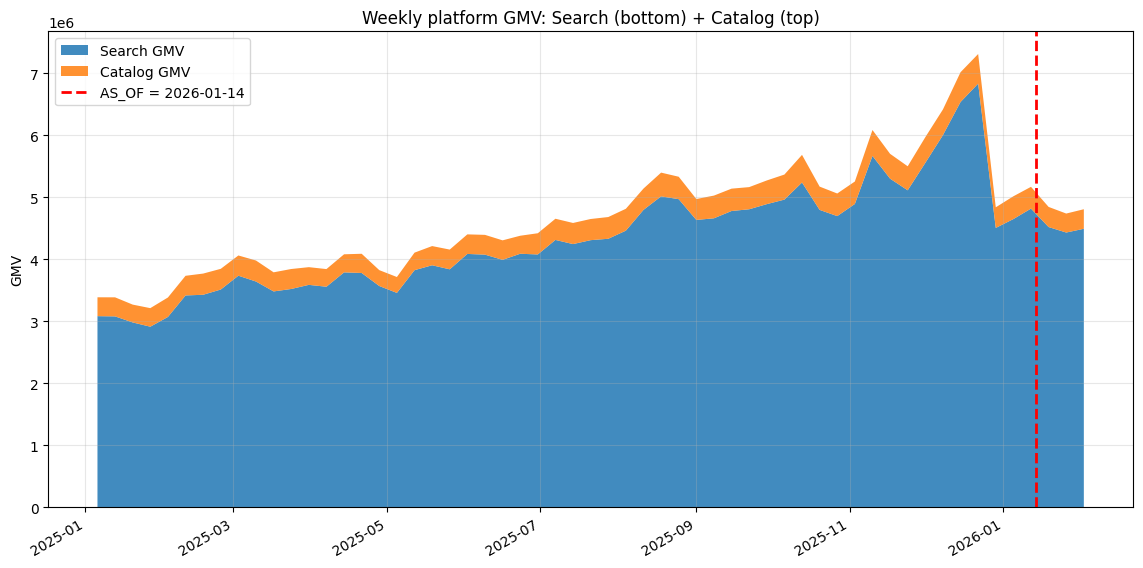

In [18]:
# STACKED AREA: CEARCH + CATALOG
weeks = weekly_full["week"].to_list()
search_vals = weekly_full["gmv_search_sum"].to_numpy()
cat_vals = weekly_full["gmv_cat_sum"].to_numpy()

fig, ax = plt.subplots(figsize = (14, 7))

ax.stackplot(
    weeks,
    search_vals,
    cat_vals,
    labels = ["Search GMV", "Catalog GMV"],
    alpha = 0.85,
)

ax.axvline(AS_OF, color = "red", linestyle = "--", linewidth = 2, label = "AS_OF = 2026-01-14")

ax.set_title("Weekly platform GMV: Search (bottom) + Catalog (top)")
ax.set_ylabel("GMV")
ax.legend(loc = "upper left")
ax.grid(alpha = 0.3)

fig.autofmt_xdate()
fig.savefig(REPORTS_GMV_DIR / "01_weekly_gmv_stacked.png", dpi = 150)
plt.show()

### **Some thoughts:**
**Global trends**
1. Platform has positive monotonic growth with local peaks;
2. Accelerating growth by the end of the year;
3. Catalog GMV is much lower compared to search GMV and does not repeat the behavior in local and global trends. So there is no flows between catalog and search. Channels have different natures, and they need to be handled differently in features.

**Local trends that depend on holidays etc**
1. Local grows: 2nd-3th weeks of February (23rd of February), 1st week of March (8th of March), 1st week of May (9th of May), 3rd-4th weeks of August (September: new School year), 1st-2nd weeks of October (Halloween), 1st week of November (4th of November), 4th week of November - 4th week of December (New Year);
2. Mounthly 2-cyclic growth after 10th and 25th days (double-payment salaries);
3. Local declines as expected after holidays and close befor salaries.

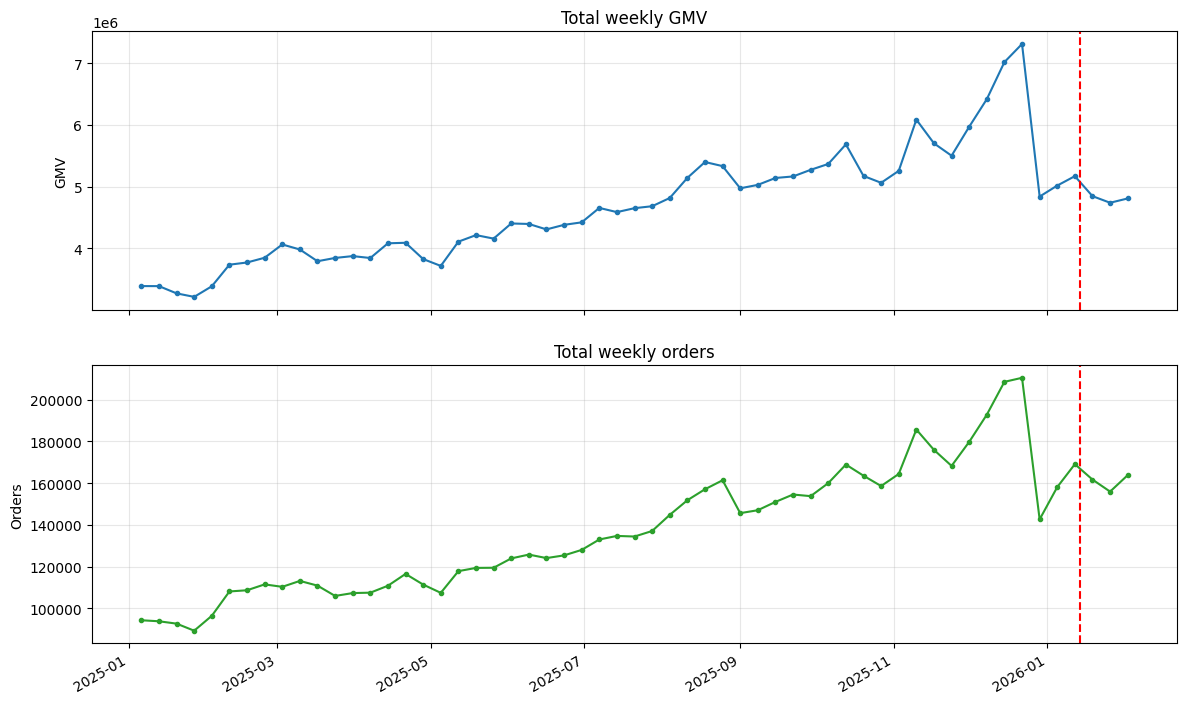

In [19]:
# OVERALL DYNAMICS OF GMV AND ORDERS BY WEEK
fig, axes = plt.subplots(2, 1, figsize = (14, 9), sharex = True)

# Total GMV
axes[0].plot(
    weekly_full["week"],
    weekly_full["gmv_sum"],
    marker = "o",
    markersize = 3,
    color = "tab:blue",
)
axes[0].axvline(AS_OF, color = "red", linestyle = "--")
axes[0].set_title("Total weekly GMV")
axes[0].set_ylabel("GMV")
axes[0].grid(alpha = 0.3)

# Orders
axes[1].plot(
    weekly_full["week"],
    weekly_full["orders_sum"],
    marker = "o",
    markersize = 3,
    color = "tab:green",
)
axes[1].axvline(AS_OF, color = "red", linestyle = "--")
axes[1].set_title("Total weekly orders")
axes[1].set_ylabel("Orders")
axes[1].grid(alpha = 0.3)

fig.autofmt_xdate()
fig.savefig(REPORTS_GMV_DIR / "02_weekly_gmv_and_orders.png", dpi = 150)
plt.show()

### **Some thoughts:**
- We can see some artefacts in compression male vs female holidays using GMV to orders ratio. For example 23rd February: the is no peak in GMV unlike number of orders compared to the week before. But looking at 8th March: we see peak in GMV, but a lower peak in number of orders. So the difference is in mean price of order.
- And so on. We can see difference in mean price of order depending on different dates. As we can compare significance of holiday, we can see trend: the lower significance, the lower mean price, so then GMV grows thank to number of orders, not to amount of the check; and inverse.

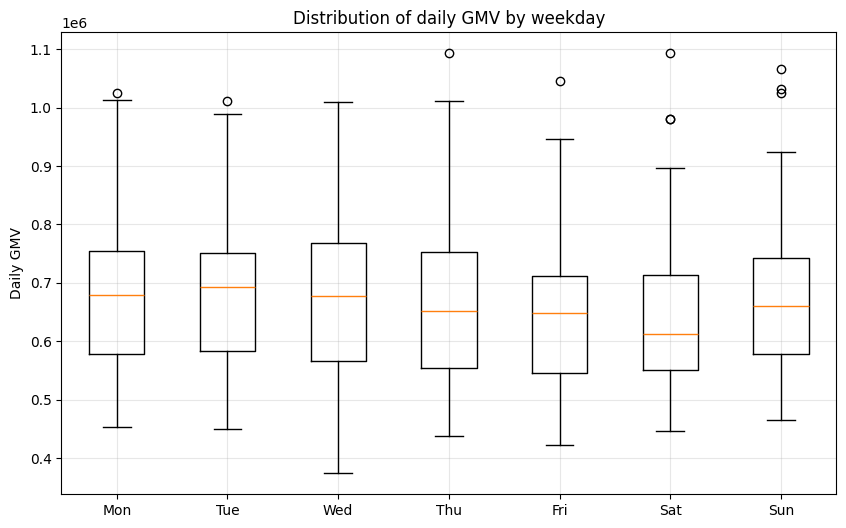

In [20]:
# DAILY AGREGATION + WEEKLY CYCLES
daily = (
    train_lf.group_by("event_date")
    .agg(
        pl.col("gmv").sum().alias("gmv_sum"),
        pl.col("to_ord").sum().alias("orders_sum"),
        pl.col("user_id").n_unique().alias("active_users"),
    )
    .with_columns(
        pl.col("event_date").dt.weekday().alias("weekday")
    )
    .sort("event_date")
    .collect()
)

WEEKDAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

data_by_weekday = [
    daily.filter(pl.col("weekday") == w)["gmv_sum"].to_numpy()
    for w in range(1, 8)
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(data_by_weekday)
ax.set_xticks(range(1, 8))
ax.set_xticklabels(WEEKDAY_LABELS)

ax.set_title("Distribution of daily GMV by weekday")
ax.set_ylabel("Daily GMV")
ax.grid(alpha=0.3)

fig.savefig(REPORTS_GMV_DIR / "03_weekday_seasonality_boxplot.png", dpi = 150)
plt.show()

shape: (7, 3)
┌─────────┬────────────────┬──────────────────┐
│ weekday ┆ mean_daily_gmv ┆ median_daily_gmv │
│ ---     ┆ ---            ┆ ---              │
│ i8      ┆ f64            ┆ f64              │
╞═════════╪════════════════╪══════════════════╡
│ 1       ┆ 677063.643419  ┆ 678636.214725    │
│ 2       ┆ 677530.675163  ┆ 693220.787494    │
│ 3       ┆ 675413.185004  ┆ 677339.591924    │
│ 4       ┆ 664661.151659  ┆ 651463.715811    │
│ 5       ┆ 638763.600888  ┆ 648399.274677    │
│ 6       ┆ 643691.939358  ┆ 612042.581209    │
│ 7       ┆ 680164.358276  ┆ 660962.707646    │
└─────────┴────────────────┴──────────────────┘


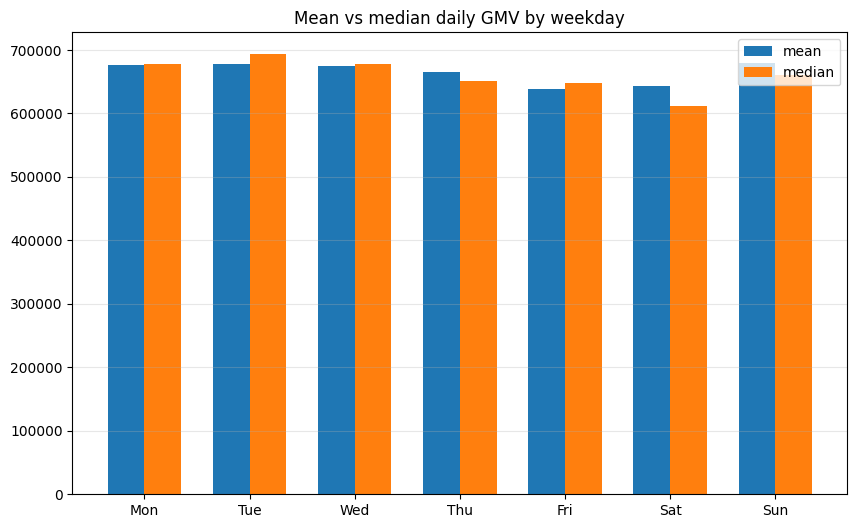

In [21]:
# WEEKLY MEANS AND MEDIANS OF GMV AGREGATED BY DAYS
weekday_stats = (
    daily.group_by("weekday")
    .agg(
        pl.col("gmv_sum").mean().alias("mean_daily_gmv"),
        pl.col("gmv_sum").median().alias("median_daily_gmv"),
    )
    .sort("weekday")
)

print(weekday_stats)

x = np.arange(1, 8)
width = 0.35

fig, ax = plt.subplots(figsize = (10, 6))

ax.bar(x - width / 2, weekday_stats["mean_daily_gmv"], width = width, label = "mean")
ax.bar(x + width / 2, weekday_stats["median_daily_gmv"], width = width, label = "median")

ax.set_xticks(x)
ax.set_xticklabels(WEEKDAY_LABELS)

ax.set_title("Mean vs median daily GMV by weekday")
ax.legend()
ax.grid(alpha = 0.3, axis = "y")

fig.savefig(REPORTS_GMV_DIR / "04_weekday_mean_median.png", dpi = 150)
plt.show()

### **Thoughts:**
- Interesting that at the beginning of the week users generate higher GMV;
- At the beginning of the week median can be higher than mean, the absolute opposite on weekends. As we can see thank to boxplots because of increasing outliers' amount. Less group of consumers gpoduce higher cheques than a tipical platform user;
- Also Tuesday makes as wonder if there’s a pattern here in fact of a noticeable difference between mean and median, the 2nd of each is higher.

*At any point it's necessery to prove statistic significance of differences*

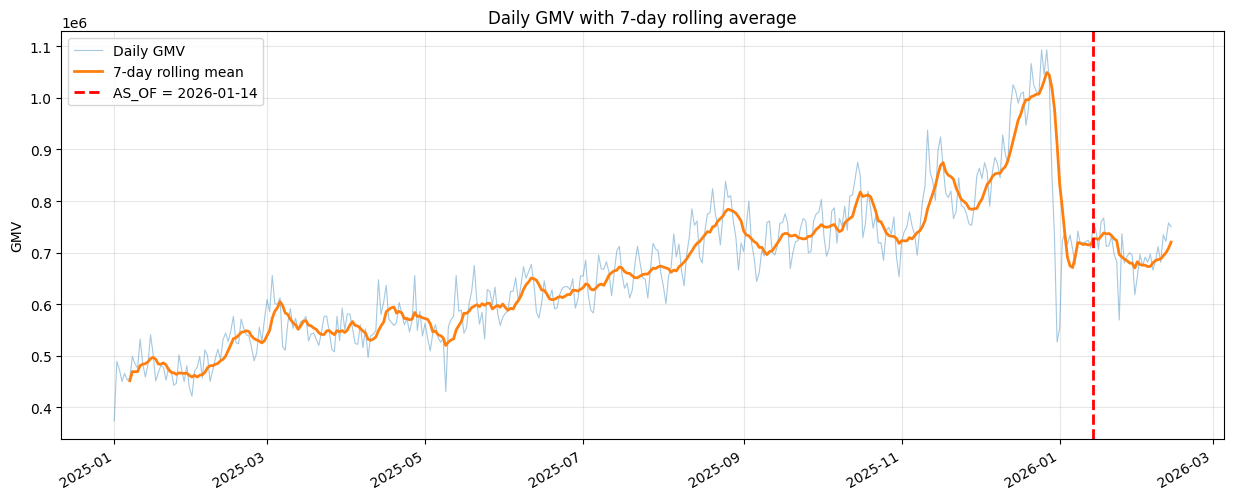

In [22]:
# DAILY DINAMIC CHART WITH AS_OF
daily_sorted = daily.sort("event_date")

dates = daily_sorted["event_date"].to_list()
gmv = daily_sorted["gmv_sum"].to_numpy()

# Weekly rolling mean
window = 7
rolling_mean = pd.Series(gmv).rolling(window).mean().to_numpy()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(dates, gmv, alpha = 0.4, linewidth = 0.8, label = "Daily GMV")
ax.plot(dates, rolling_mean, color = "tab:orange", linewidth = 2, label = f"7-day rolling mean")
ax.axvline(AS_OF, color = "red", linestyle = "--", linewidth = 2, label = "AS_OF = 2026-01-14")

ax.set_title("Daily GMV with 7-day rolling average")
ax.set_ylabel("GMV")
ax.legend()
ax.grid(alpha = 0.3)

fig.autofmt_xdate()
fig.savefig(REPORTS_GMV_DIR / "05_daily_gmv_rolling.png", dpi = 150)
plt.show()

### **Thoughts:**
- Our previous thoughts are getting more plausible after taking a glimpse of daily GMV with 7-day rolling average gragh. As we can see, oscillations are occurring. Which is very important, oscillations are stable for some horizon like local 2-4 weeks, discarding the positive shocks of the festive hustle and bustle. So if we look at 1st-3rd weeks of February we can notice this pattern. Similar patterns are noticeable on 3rd week of May - 1st week of June, 4th week of June - 2nd week of July etc.;
- As we look closely to `AS_OF` timepos, we can notice how consumption is adjusted after the New Year holidays, than enters the next monthly phase of the recession from 3rd week of January to 2nd week of February. This pattern is similar to the situation during the same period of 2025 year;
- Since this moment we can project the experience of 2025 onto the target period of 2026, adjusting for the annual cycle.

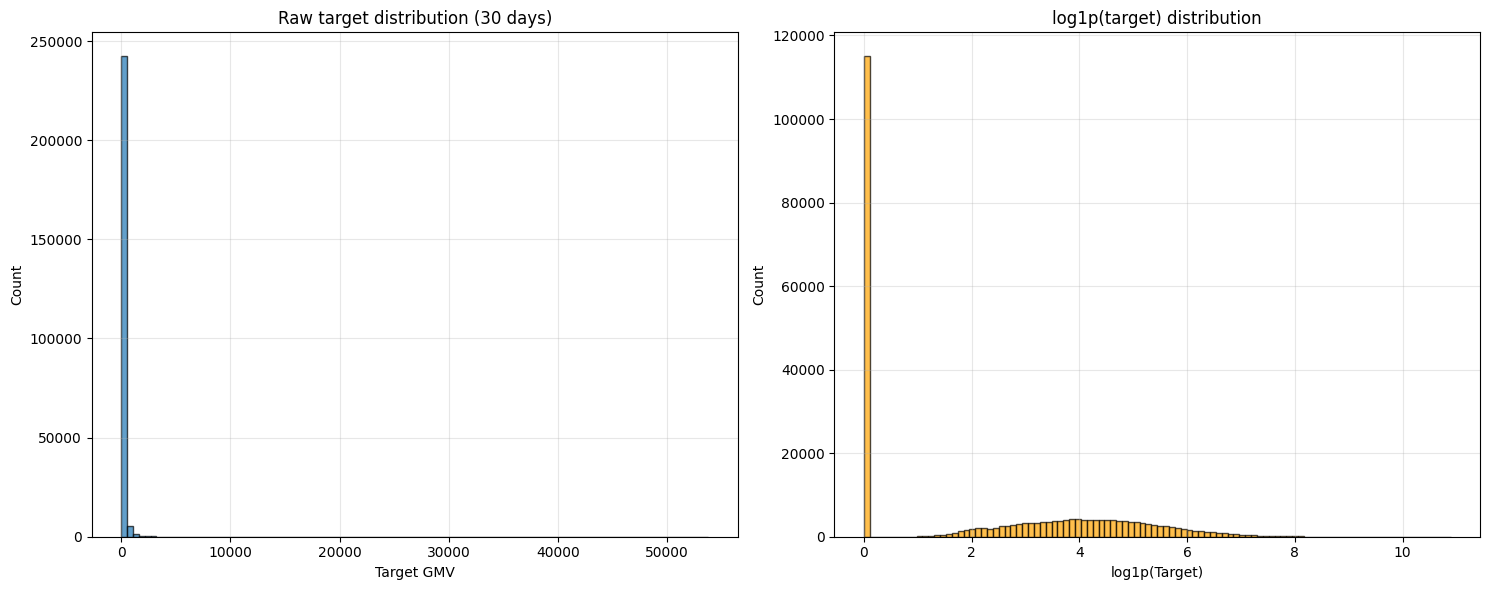

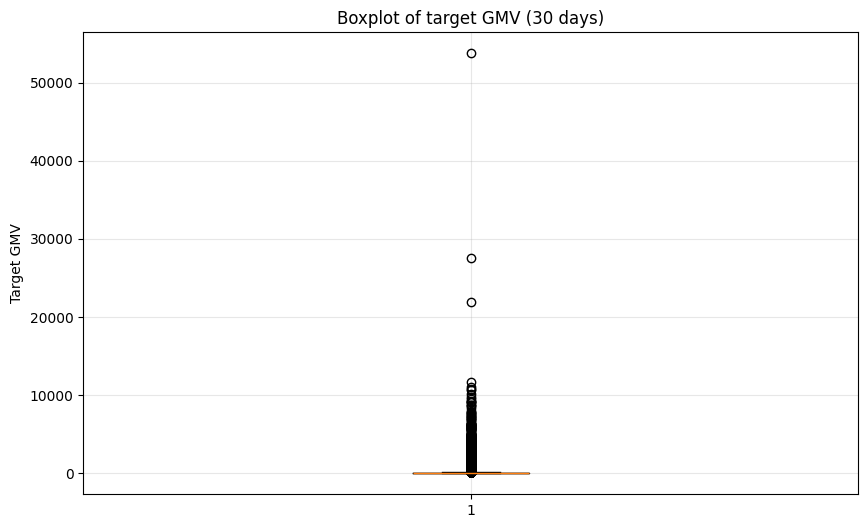

Target statistics (30 days):
Mean: 84.03
Median: 7.89
Max: 53746.95
Zero share: 0.4593


In [23]:
# TARGET DISTRIBUTION
target_vals = cv_target["target"].to_numpy()
target_log = np.log1p(target_vals)

fig, axes = plt.subplots(1, 2, figsize = (15, 6))

# Raw target
axes[0].hist(target_vals, bins = 100, alpha = 0.7, edgecolor = 'black')
axes[0].set_title("Raw target distribution (30 days)")
axes[0].set_xlabel("Target GMV")
axes[0].set_ylabel("Count")
axes[0].grid(alpha = 0.3)

# Log1p target
axes[1].hist(target_log, bins = 100, alpha = 0.7, edgecolor = 'black', color = 'orange')
axes[1].set_title("log1p(target) distribution")
axes[1].set_xlabel("log1p(Target)")
axes[1].set_ylabel("Count")
axes[1].grid(alpha = 0.3)

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "06_target_distribution.png", dpi = 150)
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize = (10, 6))
ax.boxplot(target_vals, vert=True)
ax.set_title("Boxplot of target GMV (30 days)")
ax.set_ylabel("Target GMV")
ax.grid(alpha = 0.3)
fig.savefig(REPORTS_GMV_DIR / "07_target_boxplot.png", dpi = 150)
plt.show()

# Statistics
print("Target statistics (30 days):")
print(f"Mean: {target_vals.mean():.2f}")
print(f"Median: {np.median(target_vals):.2f}")
print(f"Max: {target_vals.max():.2f}")
print(f"Zero share: {(target_vals == 0).mean():.4f}")

### **Thougts:**
- Raw distribution of target has a very heavy tail at zero. Approximately 46% of users have a zero cheque within a 30‑day horizon;
- Since zero‑users are heterogeneous, a detailed analysis of this particular category is required. However, at this stage, a decision is made to study GMV based on positively defined results. 

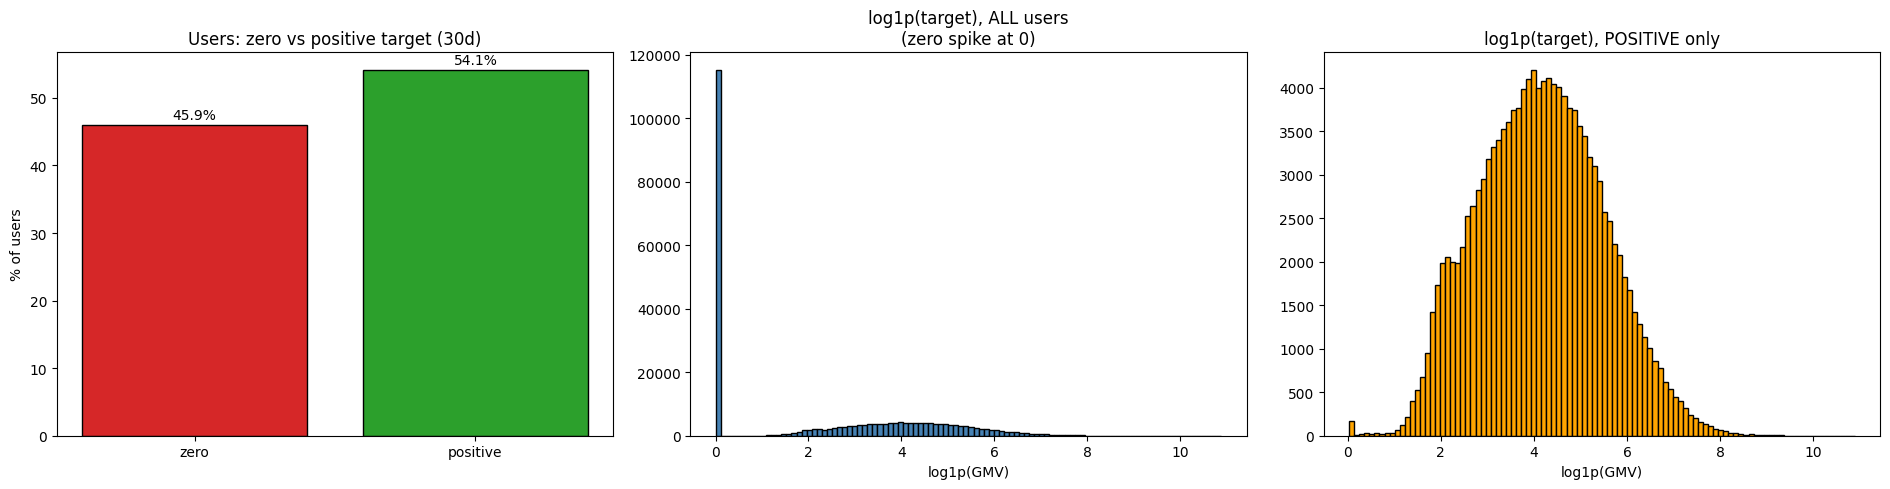

zero share: 0.4593
positive only: mean = 155.43, median = 61.36, q90 = 361.67, q99 = 1396.32, max = 53746.95


In [24]:
# TARGET (ZERO AWARE) DISTRIBUTION
target_vals = cv_target["target"].to_numpy()
pos_vals = target_vals[target_vals > 0]
zero_share = (target_vals == 0).mean()

fig, axes = plt.subplots(1, 3, figsize = (19, 5))

# Proportion of zeros and positive values
axes[0].bar(
    ["zero", "positive"],
    [zero_share * 100, (1 - zero_share) * 100],
    color = ["#d62728", "#2ca02c"],
    edgecolor = "black",
)
axes[0].set_title("Users: zero vs positive target (30d)")
axes[0].set_ylabel("% of users")
for i, v in enumerate([zero_share * 100, (1 - zero_share) * 100]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha = "center")

# log1p for everyone: peak of zeros is visible.
axes[1].hist(np.log1p(target_vals), bins = 100, color = "steelblue", edgecolor = "black")
axes[1].set_title("log1p(target), ALL users\n(zero spike at 0)")
axes[1].set_xlabel("log1p(GMV)")

# log1p only for positive cases: form of buyer distribution
axes[2].hist(np.log1p(pos_vals), bins = 100, color = "orange", edgecolor = "black")
axes[2].set_title("log1p(target), POSITIVE only")
axes[2].set_xlabel("log1p(GMV)")

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "08_target_zero_aware.png", dpi = 150)
plt.show()

print(f"zero share: {zero_share:.4f}")
print(
    f"positive only: mean = {pos_vals.mean():.2f}, "
    f"median = {np.median(pos_vals):.2f}, "
    f"q90 = {np.quantile(pos_vals, 0.9):.2f}, "
    f"q99 = {np.quantile(pos_vals, 0.99):.2f}, "
    f"max = {pos_vals.max():.2f}"
)

### **Thougts:**
- Now we can see the distribution by classes in the sense of Bernoulli. And so we considering a high-entropy situation (46% zero costs vs 54% positive costs classes). It means that for model we must work in two stages: if it is a zero/positive cheque, and then how much;
- If we consider the log1p(target) distribution without zero‑users, we can observe an approximation to a normal distribution. It may be very good news because it’s something we can work with, and with a certain level of confidence, we can rely on the properties of the normal distribution. But we need to make sure of this;
- We noticed that even after filtering by positive cheque, the graph still contains a large number of near‑zero values (about 200). This is an artifact of receipts for 1 ruble (promotions, bonuses, etc.). We will need to take this artifact into account when feature engineering and performing corrective filtering.

ENTROPY ANALYSIS
Zero users: 114835 (0.4593)
Positive users: 135165 (0.5407)

Entropy: 0.6898 nats
Max entropy (p = 0.5): 0.6931 nats
Min entropy (p = 0 or 1): 0.0000 nats
Relative entropy: 0.9952 (99.52%)

NORMALITY TESTS ON log1p(target) [positive users only]
Sample size: 135165
Mean: 4.1470
Std: 1.3362
Skewness: 0.1221
Kurtosis: -0.3172

Anderson-Darling test:
Statistic: 100.9709
p-value: 1.000000e-02
RESULT: REJECT normality at 5% level (p < 0.05)

Kolmogorov-Smirnov test (with estimated parameters):
Statistic: 0.017845
p-value: 8.074856e-38
RESULT: REJECT normality (p < 0.05)



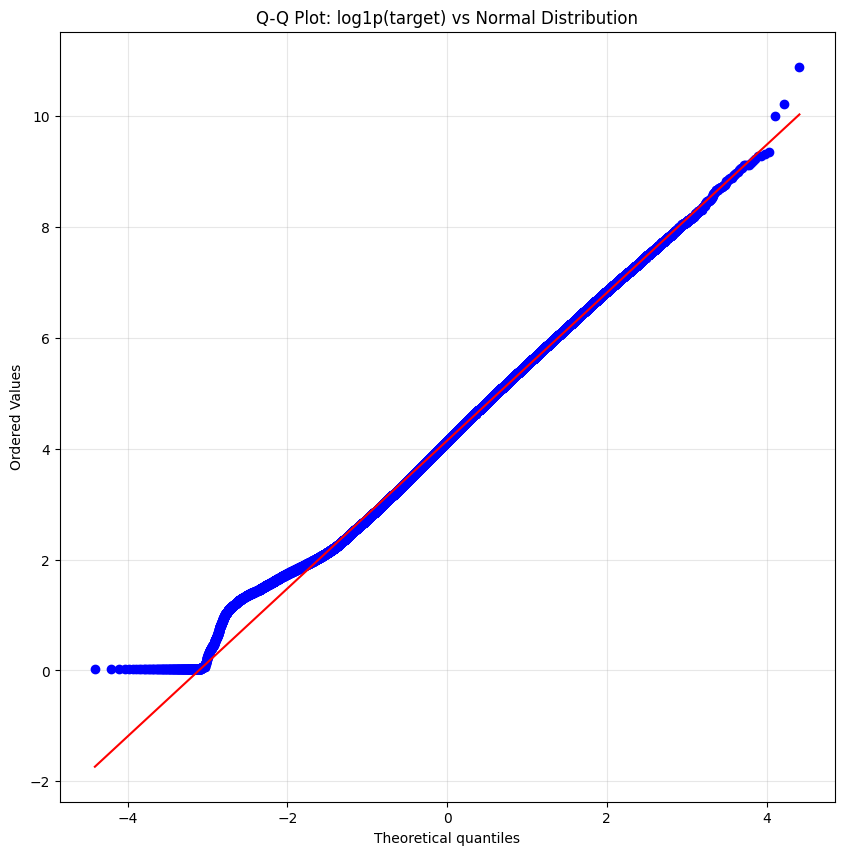

In [25]:
# BINARY-CLASS ENTROPY & NORMALITY TESTS
# Taking positive values from the local target (30 days)
target_vals = cv_target["target"].to_numpy()
pos_vals = target_vals[target_vals > 0]
pos_log = np.log1p(pos_vals)

# BINARY-CLASS ENTROPY (NATS)
n_total = len(target_vals)
n_zero = (target_vals == 0).sum()
n_pos = (target_vals > 0).sum()

p_zero = n_zero / n_total
p_pos = n_pos / n_total

H = -p_zero * np.log(p_zero) - p_pos * np.log(p_pos)
H_max = np.log(2)
H_min = 0.0

print("ENTROPY ANALYSIS")
print(f"Zero users: {n_zero} ({p_zero:.4f})")
print(f"Positive users: {n_pos} ({p_pos:.4f})\n")
print(f"Entropy: {H:.4f} nats")
print(f"Max entropy (p = 0.5): {H_max:.4f} nats")
print(f"Min entropy (p = 0 or 1): {H_min:.4f} nats")
print(f"Relative entropy: {H / H_max:.4f} ({H / H_max * 100:.2f}%)\n")

# NORMALITY TESTS
print("NORMALITY TESTS ON log1p(target) [positive users only]")
print(f"Sample size: {len(pos_log)}")
print(f"Mean: {pos_log.mean():.4f}")
print(f"Std: {pos_log.std():.4f}")
print(f"Skewness: {stats.skew(pos_log):.4f}")
print(f"Kurtosis: {stats.kurtosis(pos_log):.4f}\n")

# Anderson-Darling test
ad_result = stats.anderson(pos_log, dist = 'norm', method = 'interpolate')

print("Anderson-Darling test:")
print(f"Statistic: {ad_result.statistic:.4f}")
print(f"p-value: {ad_result.pvalue:.6e}")

if ad_result.pvalue > 0.05:
    print(f"RESULT: FAIL TO REJECT normality at 5% level (p > 0.05)\n")
else:
    print(f"RESULT: REJECT normality at 5% level (p < 0.05)\n")

# Kolmogorov-Smirnov test with estimated parameters (Lilliefors)
# Estimate the mean and standard deviation from log1p(target) data
mu = pos_log.mean()
sigma = pos_log.std()

ks_stat, ks_pvalue = stats.kstest(pos_log, 'norm', args = (mu, sigma))

print("Kolmogorov-Smirnov test (with estimated parameters):")
print(f"Statistic: {ks_stat:.6f}")
print(f"p-value: {ks_pvalue:.6e}")
if ks_pvalue > 0.05:
    print(f"RESULT: FAIL TO REJECT normality (p > 0.05)")
else:
    print(f"RESULT: REJECT normality (p < 0.05)\n")

# QQ-PLOT
fig, ax = plt.subplots(figsize = (10, 10))

stats.probplot(pos_log, dist = "norm", plot = ax)
ax.set_title("Q-Q Plot: log1p(target) vs Normal Distribution")
ax.grid(alpha = 0.3)

fig.savefig(REPORTS_GMV_DIR / "09_qq_plot_log1p.png", dpi = 150)
plt.show()

### **Thoughts:**
- Thus, the analysis of the log1p(target) distribution with a positive sum revealed a significant difference from the normal distribution. The problem is that with such a large sample, even a minimal deviation will yield a significant result. We cannot intuitively use the properties of the normal distribution to work with our sample;
- Q-Q Plot shows where the significant difference appears: observed tails are significantly heavier than the theoretical distribution. What’s interesting is that, in fact, these are special behavioral patterns that need to be used.

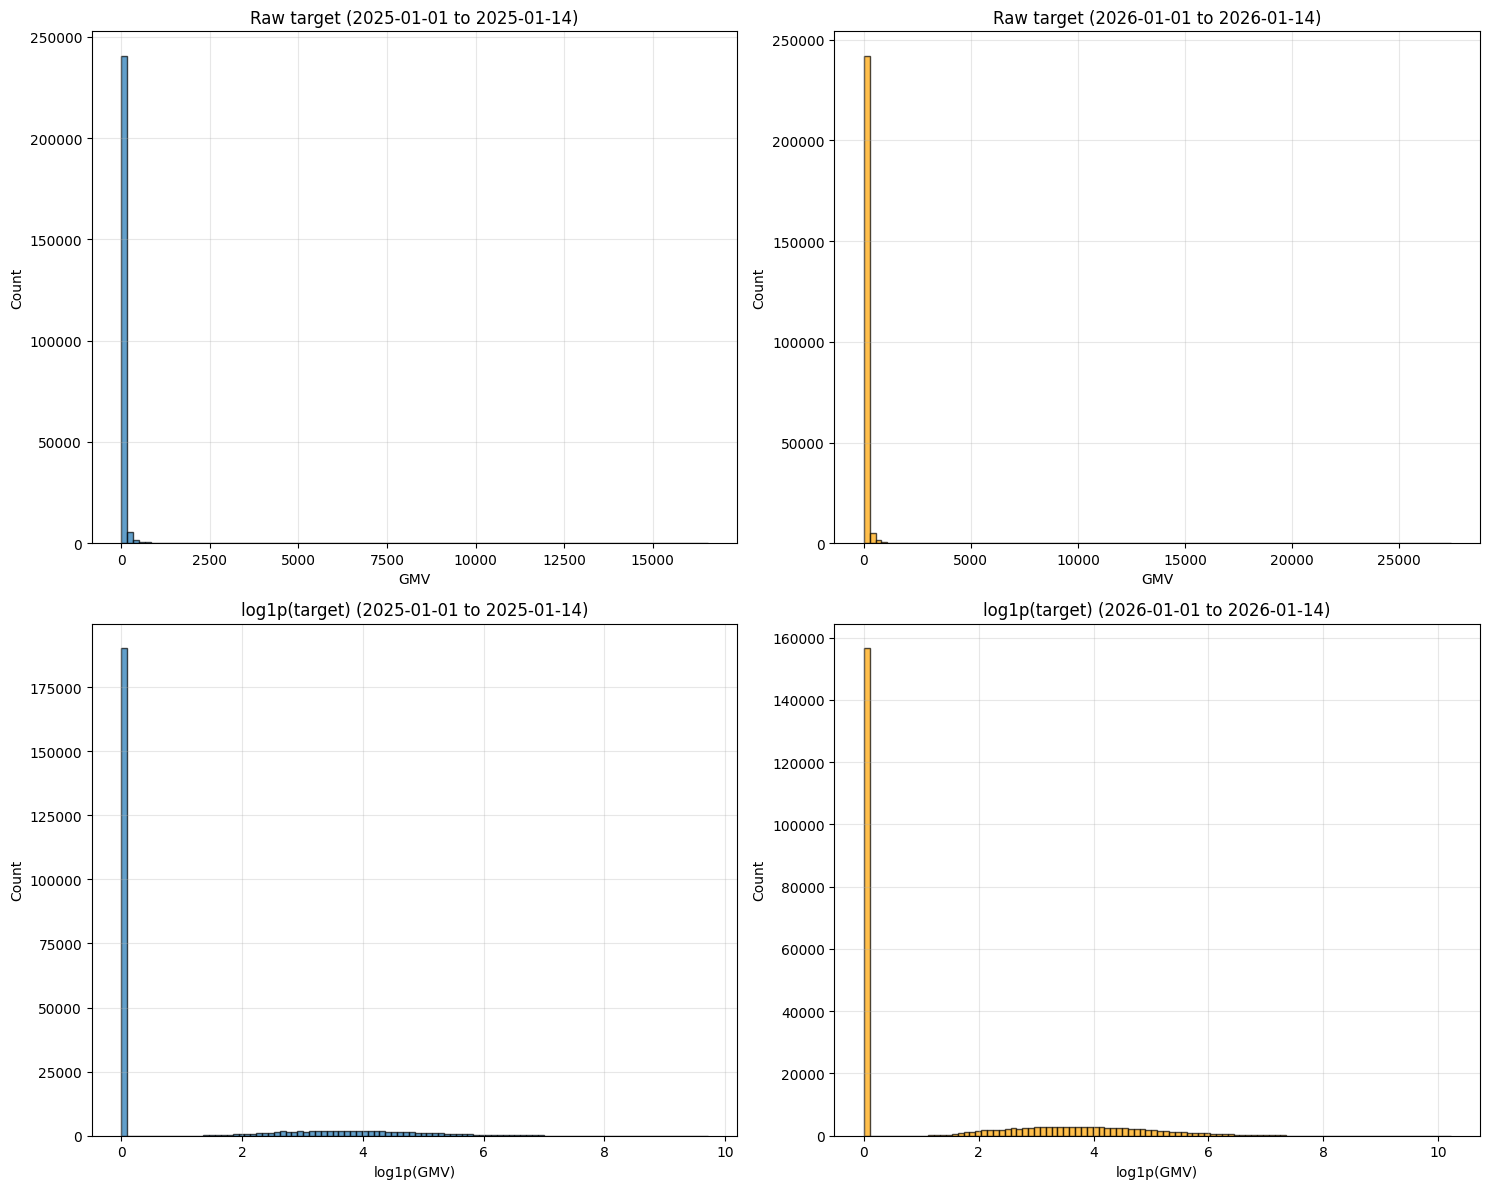

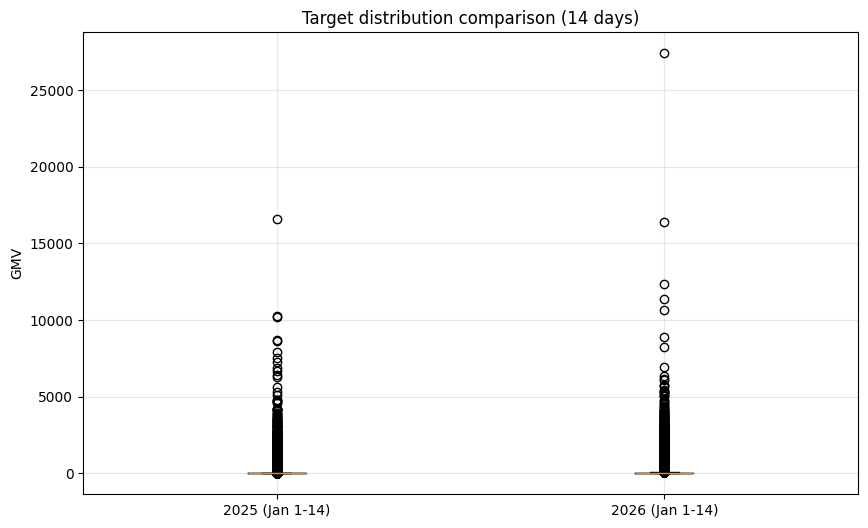

Statistics for 2025 (Jan 1-14):
Mean: 26.32
Median: 0.00
Max: 16564.24
Zero share: 0.7604

Statistics for 2026 (Jan 1-14):
Mean: 39.75
Median: 0.00
Max: 27404.71
Zero share: 0.6256


In [26]:
# TARGET COMPARISON 14-DAYS PERIODS (2025 VS 2026)
# Period from 2025-01-01 to 2025-01-14
period_2025_start = date(2025, 1, 1)
period_2025_end = date(2025, 1, 14)

target_2025 = (
    train_lf.filter(
        (pl.col("event_date") >= period_2025_start) &
        (pl.col("event_date") <= period_2025_end)
    )
    .group_by("user_id")
    .agg(pl.col("gmv").sum().alias("target"))
    .collect()
)

# Period from 2026-01-01 to 2026-01-14
period_2026_start = date(2026, 1, 1)
period_2026_end = date(2026, 1, 14)

target_2026 = (
    train_lf.filter(
        (pl.col("event_date") >= period_2026_start) &
        (pl.col("event_date") <= period_2026_end)
    )
    .group_by("user_id")
    .agg(pl.col("gmv").sum().alias("target"))
    .collect()
)

# Combine it with the complete list of users
all_users = cv_target.select("user_id")

target_2025 = all_users.join(target_2025, on = "user_id", how = "left").with_columns(
    pl.col("target").fill_null(0.0)
)

target_2026 = all_users.join(target_2026, on = "user_id", how = "left").with_columns(
    pl.col("target").fill_null(0.0)
)

vals_2025 = target_2025["target"].to_numpy()
vals_2026 = target_2026["target"].to_numpy()

log_2025 = np.log1p(vals_2025)
log_2026 = np.log1p(vals_2026)

fig, axes = plt.subplots(2, 2, figsize = (15, 12))

# 2025 raw
axes[0, 0].hist(vals_2025, bins = 100, alpha = 0.7, edgecolor = 'black')
axes[0, 0].set_title("Raw target (2025-01-01 to 2025-01-14)")
axes[0, 0].set_xlabel("GMV")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha = 0.3)

# 2026 raw
axes[0, 1].hist(vals_2026, bins = 100, alpha = 0.7, edgecolor = 'black', color = 'orange')
axes[0, 1].set_title("Raw target (2026-01-01 to 2026-01-14)")
axes[0, 1].set_xlabel("GMV")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha = 0.3)

# 2025 log1p
axes[1, 0].hist(log_2025, bins = 100, alpha = 0.7, edgecolor = 'black')
axes[1, 0].set_title("log1p(target) (2025-01-01 to 2025-01-14)")
axes[1, 0].set_xlabel("log1p(GMV)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(alpha = 0.3)

# 2026 log1p
axes[1, 1].hist(log_2026, bins = 100, alpha = 0.7, edgecolor = 'black', color = 'orange')
axes[1, 1].set_title("log1p(target) (2026-01-01 to 2026-01-14)")
axes[1, 1].set_xlabel("log1p(GMV)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(alpha = 0.3)

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "10_target_comparison_14days.png", dpi = 150)
plt.show()

# Boxplot comparison
fig, ax = plt.subplots(figsize = (10, 6))
ax.boxplot([vals_2025, vals_2026], tick_labels = ["2025 (Jan 1-14)", "2026 (Jan 1-14)"])
ax.set_title("Target distribution comparison (14 days)")
ax.set_ylabel("GMV")
ax.grid(alpha = 0.3)
fig.savefig(REPORTS_GMV_DIR / "11_target_boxplot_comparison.png", dpi = 150)
plt.show()

# Statistics
print("Statistics for 2025 (Jan 1-14):")
print(f"Mean: {vals_2025.mean():.2f}")
print(f"Median: {np.median(vals_2025):.2f}")
print(f"Max: {vals_2025.max():.2f}")
print(f"Zero share: {(vals_2025 == 0).mean():.4f}")

print("\nStatistics for 2026 (Jan 1-14):")
print(f"Mean: {vals_2026.mean():.2f}")
print(f"Median: {np.median(vals_2026):.2f}")
print(f"Max: {vals_2026.max():.2f}")
print(f"Zero share: {(vals_2026 == 0).mean():.4f}")

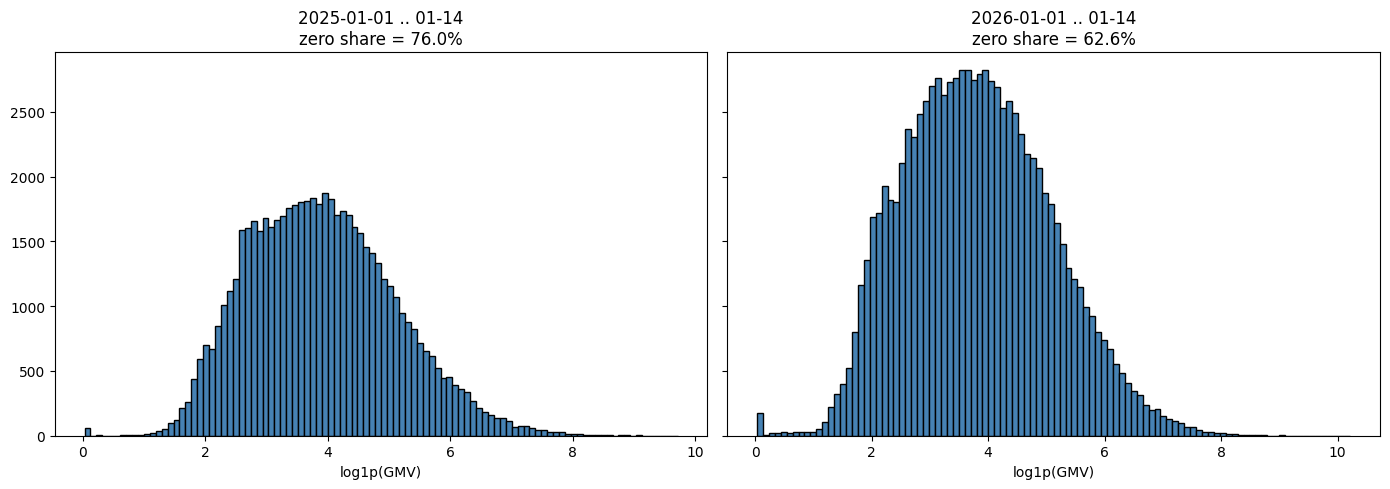

In [27]:
# TARGET (ZERO AWARE) COMPARISON 14-DAYS PERIODS (2025 VS 2026)
fig, axes = plt.subplots(1, 2, figsize = (14, 5), sharey = True)

for ax, vals, title in [
    (axes[0], vals_2025, "2025-01-01 .. 01-14"),
    (axes[1], vals_2026, "2026-01-01 .. 01-14"),
]:
    pos = vals[vals > 0]
    zs = (vals == 0).mean()
    ax.hist(np.log1p(pos), bins = 100, color = "steelblue", edgecolor = "black")
    ax.set_title(f"{title}\nzero share = {zs:.1%}")
    ax.set_xlabel("log1p(GMV)")

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "12_target_14d_zero_aware.png", dpi = 150)
plt.show()

### **Thoughts:**
- The graphs visually show an identical shape of the distributions, but the number of zero‑users has decreased from 76% to 62.6% (-17% regarding). The number of buyers has increased;
- This means that when training the model on data from 2025, we are not sure if will not get concept drift, and this is very important. We should explore dynamics in user structure and adjust mechanisms for the trend.

In [28]:
# GMV CONCENTRATION: IDENTIFICATION OF TOP GROUPS
# Calculate the total GMV for the history up to AS_OF
historical_gmv = (
    train_lf.filter(pl.col("event_date") <= AS_OF)
    .group_by("user_id")
    .agg(pl.col("gmv").sum().alias("total_gmv"))
    .sort("total_gmv", descending = True)
    .collect()
)

# Combine it with the complete list of users
historical_gmv = all_users.join(historical_gmv, on = "user_id", how = "left").with_columns(
    pl.col("total_gmv").fill_null(0.0)
).sort("total_gmv", descending = True)

# Identify the top groups
n_users = len(historical_gmv)
top_1_pct = int(n_users * 0.01)
top_5_pct = int(n_users * 0.05)
top_10_pct = int(n_users * 0.10)
top_20_pct = int(n_users * 0.20)
top_50_pct = int(n_users * 0.50)

print(f"Total users: {n_users}")
print(f"Top 1%: {top_1_pct} users")
print(f"Top 5%: {top_5_pct} users")
print(f"Top 10%: {top_10_pct} users")
print(f"Top 20%: {top_20_pct} users")
print(f"Top 50%: {top_50_pct} users")

# Sort and add a rank
historical_gmv = historical_gmv.with_row_index("rank")

# Create flags for top groups
historical_gmv = historical_gmv.with_columns([
    (pl.col("rank") < top_1_pct).alias("is_top_1"),
    (pl.col("rank") < top_5_pct).alias("is_top_5"),
    (pl.col("rank") < top_10_pct).alias("is_top_10"),
    (pl.col("rank") < top_20_pct).alias("is_top_20"),
    (pl.col("rank") < top_50_pct).alias("is_top_50"),
])

print("\nHistorical GMV distribution:")
print(historical_gmv.head(10))

Total users: 250000
Top 1%: 2500 users
Top 5%: 12500 users
Top 10%: 25000 users
Top 20%: 50000 users
Top 50%: 125000 users

Historical GMV distribution:
shape: (10, 8)
┌──────┬─────────┬───────────────┬──────────┬──────────┬───────────┬───────────┬───────────┐
│ rank ┆ user_id ┆ total_gmv     ┆ is_top_1 ┆ is_top_5 ┆ is_top_10 ┆ is_top_20 ┆ is_top_50 │
│ ---  ┆ ---     ┆ ---           ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---       │
│ u32  ┆ i64     ┆ f64           ┆ bool     ┆ bool     ┆ bool      ┆ bool      ┆ bool      │
╞══════╪═════════╪═══════════════╪══════════╪══════════╪═══════════╪═══════════╪═══════════╡
│ 0    ┆ 466880  ┆ 121304.222654 ┆ true     ┆ true     ┆ true      ┆ true      ┆ true      │
│ 1    ┆ 621247  ┆ 106510.638295 ┆ true     ┆ true     ┆ true      ┆ true      ┆ true      │
│ 2    ┆ 747516  ┆ 98335.654473  ┆ true     ┆ true     ┆ true      ┆ true      ┆ true      │
│ 3    ┆ 204668  ┆ 97832.371391  ┆ true     ┆ true     ┆ true      ┆ true      ┆ true   

Contribution to local target (30 days, 2026-01-15 to 2026-02-13):
  Top 1%: 0.1200 (12.00%)
  Top 5%: 0.3081 (30.81%)
  Top 10%: 0.4448 (44.48%)
  Top 20%: 0.6247 (62.47%)
  Top 50%: 0.8860 (88.60%)


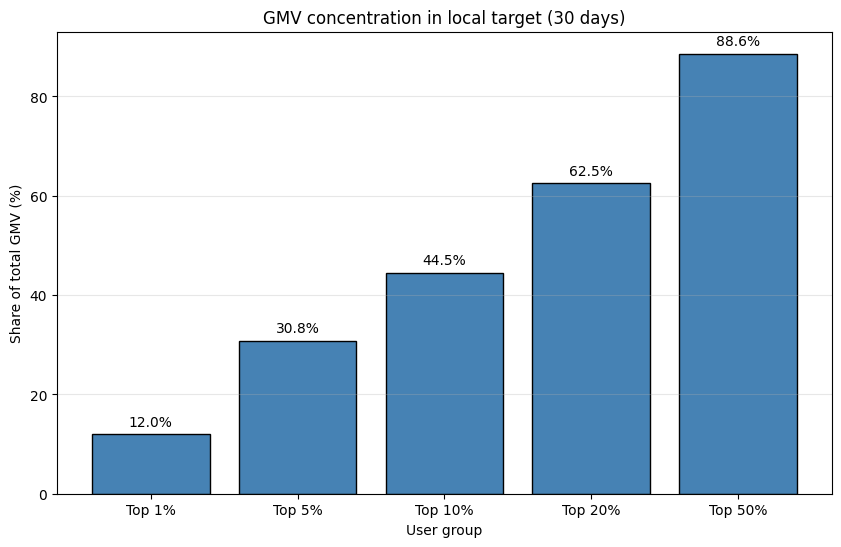

In [29]:
# LOCAL GMV CONCENTRATION
# Combine historical top‑groups with a local target.
target_with_groups = cv_target.join(
    historical_gmv.select(["user_id", "is_top_1", "is_top_5", "is_top_10", "is_top_20", "is_top_50"]),
    on = "user_id",
    how = "left"
)

# Calculate the contribution of each top group.
total_target_gmv = target_with_groups["target"].sum()

contribution_local = {
    "Top 1%": target_with_groups.filter(pl.col("is_top_1"))["target"].sum() / total_target_gmv,
    "Top 5%": target_with_groups.filter(pl.col("is_top_5"))["target"].sum() / total_target_gmv,
    "Top 10%": target_with_groups.filter(pl.col("is_top_10"))["target"].sum() / total_target_gmv,
    "Top 20%": target_with_groups.filter(pl.col("is_top_20"))["target"].sum() / total_target_gmv,
    "Top 50%": target_with_groups.filter(pl.col("is_top_50"))["target"].sum() / total_target_gmv,
}

print("Contribution to local target (30 days, 2026-01-15 to 2026-02-13):")
for group, share in contribution_local.items():
    print(f"  {group}: {share:.4f} ({share*100:.2f}%)")

fig, ax = plt.subplots(figsize = (10, 6))
groups = list(contribution_local.keys())
shares = [contribution_local[g] * 100 for g in groups]

ax.bar(groups, shares, color = 'steelblue', edgecolor = 'black')
ax.set_title("GMV concentration in local target (30 days)")
ax.set_ylabel("Share of total GMV (%)")
ax.set_xlabel("User group")
ax.grid(alpha = 0.3, axis = 'y')

for i, (g, s) in enumerate(zip(groups, shares)):
    ax.text(i, s + 1, f'{s:.1f}%', ha = 'center', va = 'bottom')

fig.savefig(REPORTS_GMV_DIR / "13_gmv_concentration_local.png", dpi = 150)
plt.show()

Contribution to period 2025-01-01 to 2025-01-14 (14 days):
Top 1%: 0.1555 (15.55%)
Top 5%: 0.3942 (39.42%)
Top 10%: 0.5559 (55.59%)
Top 20%: 0.7409 (74.09%)
Top 50%: 0.9579 (95.79%)

Contribution to period 2026-01-01 to 2026-01-14 (14 days):
Top 1%: 0.1339 (13.39%)
Top 5%: 0.3483 (34.83%)
Top 10%: 0.4996 (49.96%)
Top 20%: 0.6876 (68.76%)
Top 50%: 0.9324 (93.24%)


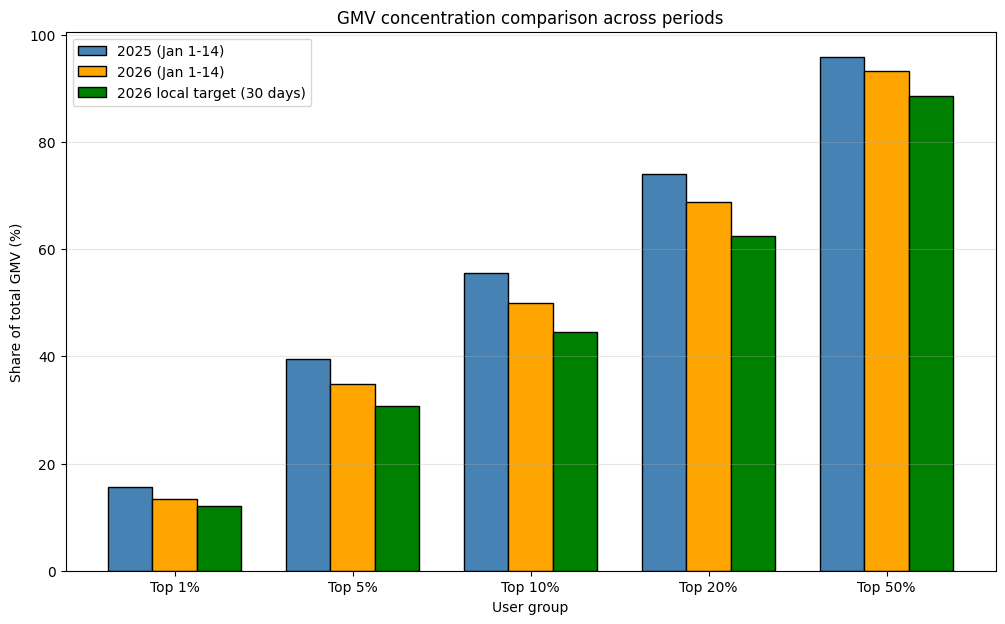

In [30]:
# LOCAL GMV CONCENTRATION COMPARISON (2025 VS 2026 VS LOCAL TARGET)
# Period from 2025-01-01 to 2025-01-14
target_2025_with_groups = target_2025.join(
    historical_gmv.select(["user_id", "is_top_1", "is_top_5", "is_top_10", "is_top_20", "is_top_50"]),
    on = "user_id",
    how = "left"
)

total_2025 = target_2025_with_groups["target"].sum()

contribution_2025 = {
    "Top 1%": target_2025_with_groups.filter(pl.col("is_top_1"))["target"].sum() / total_2025,
    "Top 5%": target_2025_with_groups.filter(pl.col("is_top_5"))["target"].sum() / total_2025,
    "Top 10%": target_2025_with_groups.filter(pl.col("is_top_10"))["target"].sum() / total_2025,
    "Top 20%": target_2025_with_groups.filter(pl.col("is_top_20"))["target"].sum() / total_2025,
    "Top 50%": target_2025_with_groups.filter(pl.col("is_top_50"))["target"].sum() / total_2025,
}

# Period from 2026-01-01 to 2026-01-14
target_2026_with_groups = target_2026.join(
    historical_gmv.select(["user_id", "is_top_1", "is_top_5", "is_top_10", "is_top_20", "is_top_50"]),
    on = "user_id",
    how = "left"
)

total_2026 = target_2026_with_groups["target"].sum()

contribution_2026 = {
    "Top 1%": target_2026_with_groups.filter(pl.col("is_top_1"))["target"].sum() / total_2026,
    "Top 5%": target_2026_with_groups.filter(pl.col("is_top_5"))["target"].sum() / total_2026,
    "Top 10%": target_2026_with_groups.filter(pl.col("is_top_10"))["target"].sum() / total_2026,
    "Top 20%": target_2026_with_groups.filter(pl.col("is_top_20"))["target"].sum() / total_2026,
    "Top 50%": target_2026_with_groups.filter(pl.col("is_top_50"))["target"].sum() / total_2026,
}

print("Contribution to period 2025-01-01 to 2025-01-14 (14 days):")
for group, share in contribution_2025.items():
    print(f"{group}: {share:.4f} ({share*100:.2f}%)")

print("\nContribution to period 2026-01-01 to 2026-01-14 (14 days):")
for group, share in contribution_2026.items():
    print(f"{group}: {share:.4f} ({share*100:.2f}%)")

# Comparison chart
fig, ax = plt.subplots(figsize = (12, 7))

x = np.arange(len(groups))
width = 0.25

ax.bar(x - width, [contribution_2025[g] * 100 for g in groups], width, 
       label = '2025 (Jan 1-14)', color = 'steelblue', edgecolor = 'black')
ax.bar(x, [contribution_2026[g] * 100 for g in groups], width, 
       label = '2026 (Jan 1-14)', color = 'orange', edgecolor = 'black')
ax.bar(x + width, [contribution_local[g] * 100 for g in groups], width, 
       label = '2026 local target (30 days)', color = 'green', edgecolor = 'black')

ax.set_xlabel("User group")
ax.set_ylabel("Share of total GMV (%)")
ax.set_title("GMV concentration comparison across periods")
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.grid(alpha = 0.3, axis = 'y')

fig.savefig(REPORTS_GMV_DIR / "14_gmv_concentration_comparison.png", dpi = 150)
plt.show()

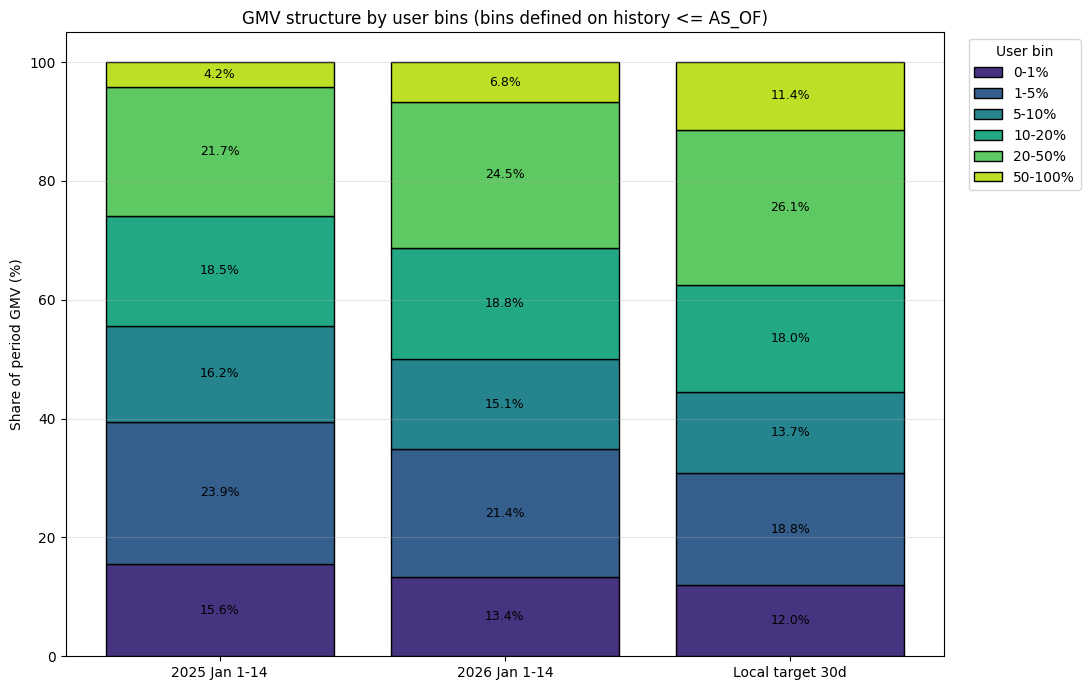

2025 {'0-1%': 15.55, '1-5%': 23.87, '5-10%': 16.16, '10-20%': 18.5, '20-50%': 21.71, '50-100%': 4.21}
2026 {'0-1%': 13.39, '1-5%': 21.45, '5-10%': 15.12, '10-20%': 18.8, '20-50%': 24.48, '50-100%': 6.76}
local {'0-1%': 12.0, '1-5%': 18.81, '5-10%': 13.67, '10-20%': 17.99, '20-50%': 26.13, '50-100%': 11.4}


In [31]:
# GMV STRUCTURE BY USER BINS
# Non‑overlapping bins by rank of the historical GMV
historical_gmv = historical_gmv.with_columns(
    pl.when(pl.col("rank") < top_1_pct).then(pl.lit("0-1%"))
    .when(pl.col("rank") < top_5_pct).then(pl.lit("1-5%"))
    .when(pl.col("rank") < top_10_pct).then(pl.lit("5-10%"))
    .when(pl.col("rank") < top_20_pct).then(pl.lit("10-20%"))
    .when(pl.col("rank") < top_50_pct).then(pl.lit("20-50%"))
    .otherwise(pl.lit("50-100%"))
    .alias("gmv_bin")
)

def bin_shares(target_df):
    """The share of GMV for each bin in the given period."""
    df = target_df.join(
        historical_gmv.select("user_id", "gmv_bin"),
        on = "user_id",
        how = "left",
    )
    total = df["target"].sum()
    g = df.group_by("gmv_bin").agg(pl.col("target").sum().alias("gmv_sum"))
    shares = {b: 0.0 for b in BIN_ORDER}
    for row in g.iter_rows(named = True):
        shares[row["gmv_bin"]] = row["gmv_sum"] / total * 100
    return [shares[b] for b in BIN_ORDER]


shares_2025 = bin_shares(target_2025)
shares_2026 = bin_shares(target_2026)
shares_local = bin_shares(cv_target)

all_shares = np.array([shares_2025, shares_2026, shares_local])  # (3 periods, 6 bins)

colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(BIN_ORDER)))

fig, ax = plt.subplots(figsize = (11, 7))

x = np.arange(3)
bottoms = np.zeros(3)

for i, b in enumerate(BIN_ORDER):
    vals = all_shares[:, i]
    ax.bar(x, vals, bottom = bottoms, color = colors[i], edgecolor = "black", label = b)
    for j, v in enumerate(vals):
        if v > 3:
            ax.text(
                x[j], bottoms[j] + v / 2,
                f"{v:.1f}%", ha = "center", va = "center", fontsize = 9,
            )
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(["2025 Jan 1-14", "2026 Jan 1-14", "Local target 30d"])
ax.set_ylabel("Share of period GMV (%)")
ax.set_title("GMV structure by user bins (bins defined on history <= AS_OF)")
ax.legend(title = "User bin", bbox_to_anchor = (1.02, 1), loc = "upper left")
ax.grid(alpha = 0.3, axis = "y")

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "15_gmv_structure_stacked.png", dpi = 150, bbox_inches = "tight")
plt.show()

for name, s in zip(["2025", "2026", "local"], [shares_2025, shares_2026, shares_local]):
    print(name, {b: round(v, 2) for b, v in zip(BIN_ORDER, s)})

### **Thoughts:**
- It’s important to note what the potential concept drift entails: the platform is becoming more mainstream, it’s no longer dependent on the best users, and is now focused on the mass audience.
- Interestingly, the top 50–100% of users show the greatest increase in shares. This does not clearly indicate that the platform has improved its conversion rate, but it shows just that in local target (30d) user is more likely to buy something compared to a 14‑day period.
- To reduce the likelihood of concept drift, we will use the sample closest in date for validation, rather than a similar one from the previous year. 

## **02 - CONVERSION & SALES FUNNEL ANALYSIS**

In [32]:
# OVERALL USER-LEVEL FUNNEL (ENTIRE PERIOD)
# For each user, checking whether they were at each stage of the funnel
user_funnel = (
    train_lf.group_by("user_id")
    .agg([
        pl.col("search").max().alias("ever_search"),
        pl.col("cat").max().alias("ever_cat"),
        pl.col("has_search_to_cart").max().alias("ever_search_to_cart"),
        pl.col("has_search_to_ord").max().alias("ever_search_to_ord"),
        pl.col("has_cat_to_cart").max().alias("ever_cat_to_cart"),
        pl.col("has_cat_to_ord").max().alias("ever_cat_to_ord"),
        (pl.col("to_cart") > 0).max().alias("ever_any_cart"),
        (pl.col("to_ord") > 0).max().alias("ever_any_order")
    ])
    .collect()
)

# Counting shares
total_users = len(user_funnel)

funnel_stats = {
    "Total users": total_users,
    "Ever used search": user_funnel["ever_search"].sum(),
    "Ever used catalog": user_funnel["ever_cat"].sum(),
    "Ever used search to cart": user_funnel["ever_search_to_cart"].sum(),
    "Ever used search to order": user_funnel["ever_search_to_ord"].sum(),
    "Ever used catalog to cart": user_funnel["ever_cat_to_cart"].sum(),
    "Ever used catalog to order": user_funnel["ever_cat_to_ord"].sum(),
    "Ever added to cart (any channel)": user_funnel["ever_any_cart"].sum(),
    "Ever ordered (any channel)": user_funnel["ever_any_order"].sum(),
}

print("FUNNEL ANALYSIS (entire period)")

for stage, count in funnel_stats.items():
    pct = count / total_users * 100
    print(f"{stage:40} {count:8,} ({pct:5.1f}%)")

print("\nConversion rates:")
print(f"Search to Cart: {user_funnel['ever_search_to_cart'].sum() / user_funnel['ever_search'].sum() * 100:.2f}%")
print(f"Search to Order: {user_funnel['ever_search_to_ord'].sum() / user_funnel['ever_search'].sum() * 100:.2f}%")
print(f"Catalog to Cart: {user_funnel['ever_cat_to_cart'].sum() / user_funnel['ever_cat'].sum() * 100:.2f}%")
print(f"Catalog to Order: {user_funnel['ever_cat_to_ord'].sum() / user_funnel['ever_cat'].sum() * 100:.2f}%")
print(f"Cart to Order: {user_funnel['ever_any_order'].sum() / user_funnel['ever_any_cart'].sum() * 100:.2f}%")

FUNNEL ANALYSIS (entire period)
Total users                               250,000 (100.0%)
Ever used search                          249,472 ( 99.8%)
Ever used catalog                         232,703 ( 93.1%)
Ever used search to cart                  245,131 ( 98.1%)
Ever used search to order                 217,778 ( 87.1%)
Ever used catalog to cart                 170,621 ( 68.2%)
Ever used catalog to order                 99,341 ( 39.7%)
Ever added to cart (any channel)          246,062 ( 98.4%)
Ever ordered (any channel)                219,168 ( 87.7%)

Conversion rates:
Search to Cart: 98.26%
Search to Order: 87.30%
Catalog to Cart: 73.32%
Catalog to Order: 42.69%
Cart to Order: 89.07%


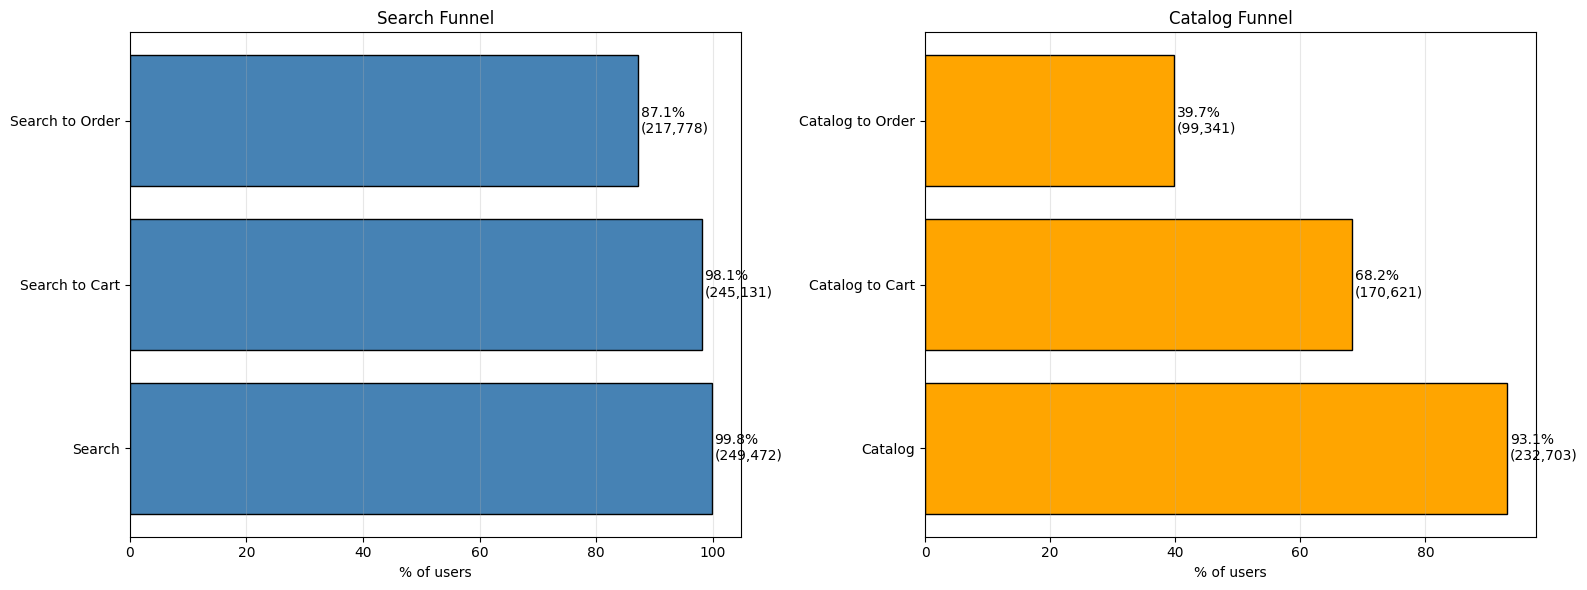

In [33]:
# GENERAL FUNNEL
# Search funnel
search_funnel = [
    ("Search", funnel_stats["Ever used search"]),
    ("Search to Cart", funnel_stats["Ever used search to cart"]),
    ("Search to Order", funnel_stats["Ever used search to order"]),
]

# Funnel for the catalog
cat_funnel = [
    ("Catalog", funnel_stats["Ever used catalog"]),
    ("Catalog to Cart", funnel_stats["Ever used catalog to cart"]),
    ("Catalog to Order", funnel_stats["Ever used catalog to order"]),
]

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Graph to search for
stages_search = [x[0] for x in search_funnel]
counts_search = [x[1] for x in search_funnel]
pcts_search = [x[1] / total_users * 100 for x in search_funnel]

axes[0].barh(stages_search, pcts_search, color = "steelblue", edgecolor = "black")
axes[0].set_xlabel("% of users")
axes[0].set_title("Search Funnel")
axes[0].grid(alpha = 0.3, axis = "x")

for i, (stage, pct, count) in enumerate(zip(stages_search, pcts_search, counts_search)):
    axes[0].text(pct + 0.5, i, f"{pct:.1f}%\n({count:,})", va = "center")

# Schedule for the catalog
stages_cat = [x[0] for x in cat_funnel]
counts_cat = [x[1] for x in cat_funnel]
pcts_cat = [x[1] / total_users * 100 for x in cat_funnel]

axes[1].barh(stages_cat, pcts_cat, color = "orange", edgecolor = "black")
axes[1].set_xlabel("% of users")
axes[1].set_title("Catalog Funnel")
axes[1].grid(alpha = 0.3, axis = "x")

for i, (stage, pct, count) in enumerate(zip(stages_cat, pcts_cat, counts_cat)):
    axes[1].text(pct + 0.5, i, f"{pct:.1f}%\n({count:,})", va = "center")

plt.tight_layout()
fig.savefig(REPORTS_CONV_FUNL_DIR / "16_funnel_overall.png", dpi = 150)
plt.show()

### **Thoughts:**
- The graph captures a fundamental difference in the behavior of users across the two channels. Search demonstrates an extremely high end‑to‑end conversion rate (87.1% of users make a purchase), while Catalog loses more than 60% of users on the path to placing an order (conversion rate of only 19.7%). This indicates that Search is the main driver of the platform’s monetization, while Catalog is an area with enormous untapped potential. For the model, this means that the predictive power of features related to Search will be significantly higher than those related to Catalog.

In [34]:
# FUNNEL BY MONTHS
# Aggregating by user and month
user_month = (
    train_lf.with_columns(
        pl.col("event_date").dt.strftime("%Y-%m").alias("month")
    )
    .group_by(["user_id", "month"])
    .agg([
        pl.col("search").max().alias("had_search"),
        pl.col("cat").max().alias("had_cat"),
        pl.col("has_search_to_cart").max().alias("had_search_to_cart"),
        pl.col("has_search_to_ord").max().alias("had_search_to_ord"),
        pl.col("has_cat_to_cart").max().alias("had_cat_to_cart"),
        pl.col("has_cat_to_ord").max().alias("had_cat_to_ord"),
        pl.col("to_cart").max().alias("had_any_cart"),
        pl.col("to_ord").max().alias("had_any_order"),
    ])
)

# Aggregating by month
monthly_funnel = (
    user_month.group_by("month")
    .agg([
        pl.col("user_id").n_unique().alias("active_users"),
        pl.col("had_search").sum().alias("search_users"),
        pl.col("had_cat").sum().alias("cat_users"),
        pl.col("had_search_to_cart").sum().alias("search_cart_users"),
        pl.col("had_search_to_ord").sum().alias("search_ord_users"),
        pl.col("had_cat_to_cart").sum().alias("cat_cart_users"),
        pl.col("had_cat_to_ord").sum().alias("cat_ord_users"),
        pl.col("had_any_cart").sum().alias("cart_users"),
        pl.col("had_any_order").sum().alias("order_users"),
    ])
    .sort("month")
    .collect()
)

print(monthly_funnel)

# Counting conversions by month
monthly_funnel = monthly_funnel.with_columns([
    (pl.col("search_cart_users") / pl.col("search_users") * 100).alias("search_to_cart_rate"),
    (pl.col("search_ord_users") / pl.col("search_users") * 100).alias("search_to_ord_rate"),
    (pl.col("cat_cart_users") / pl.col("cat_users") * 100).alias("cat_to_cart_rate"),
    (pl.col("cat_ord_users") / pl.col("cat_users") * 100).alias("cat_to_ord_rate"),
    (pl.col("order_users") / pl.col("cart_users") * 100).alias("cart_to_ord_rate"),
])

print("\nMonthly conversion rates:")
print(monthly_funnel.select([
    "month",
    "active_users",
    "search_to_cart_rate",
    "search_to_ord_rate",
    "cat_to_cart_rate",
    "cat_to_ord_rate",
    "cart_to_ord_rate",
]))

shape: (14, 10)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ month   ┆ active_use ┆ search_us ┆ cat_users ┆ … ┆ cat_cart_ ┆ cat_ord_u ┆ cart_user ┆ order_use │
│ ---     ┆ rs         ┆ ers       ┆ ---       ┆   ┆ users     ┆ sers      ┆ s         ┆ rs        │
│ str     ┆ ---        ┆ ---       ┆ i64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ u32        ┆ i64       ┆           ┆   ┆ i64       ┆ i64       ┆ i64       ┆ i64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2025-01 ┆ 189446     ┆ 183260    ┆ 103784    ┆ … ┆ 44292     ┆ 15881     ┆ 575489    ┆ 186137    │
│ 2025-02 ┆ 192145     ┆ 185385    ┆ 102316    ┆ … ┆ 43796     ┆ 16080     ┆ 586946    ┆ 196460    │
│ 2025-03 ┆ 198363     ┆ 191662    ┆ 110073    ┆ … ┆ 47203     ┆ 17650     ┆ 647410    ┆ 218129    │
│ 2025-04 ┆ 200550     ┆ 193352    ┆ 98724     ┆ … ┆ 41180     ┆ 14600     

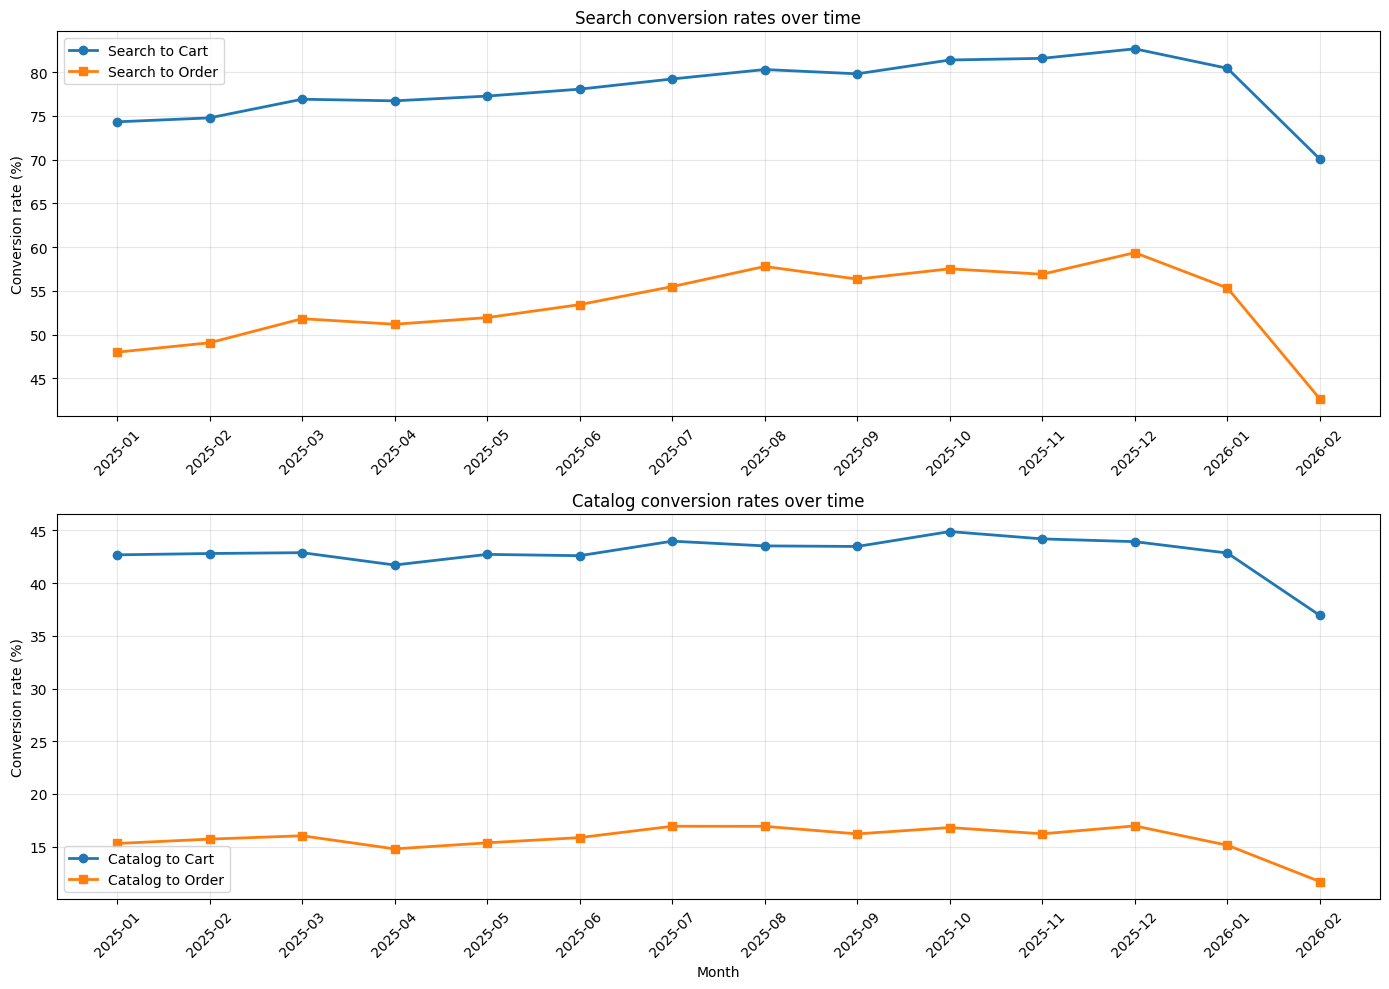

In [35]:
# VISUALIZATION OF THE CONVERSION IN TIME
months = monthly_funnel["month"].to_list()

fig, axes = plt.subplots(2, 1, figsize = (14, 10))

# Search conversion 
axes[0].plot(
    months,
    monthly_funnel["search_to_cart_rate"],
    marker = "o",
    label = "Search to Cart",
    linewidth = 2,
)
axes[0].plot(
    months,
    monthly_funnel["search_to_ord_rate"],
    marker = "s",
    label = "Search to Order",
    linewidth = 2,
)
axes[0].set_title("Search conversion rates over time")
axes[0].set_ylabel("Conversion rate (%)")
axes[0].legend()
axes[0].grid(alpha = 0.3)
axes[0].tick_params(axis = "x", rotation = 45)

# Catalog conversion
axes[1].plot(
    months,
    monthly_funnel["cat_to_cart_rate"],
    marker = "o",
    label = "Catalog to Cart",
    linewidth = 2,
)
axes[1].plot(
    months,
    monthly_funnel["cat_to_ord_rate"],
    marker = "s",
    label = "Catalog to Order",
    linewidth = 2,
)
axes[1].set_title("Catalog conversion rates over time")
axes[1].set_ylabel("Conversion rate (%)")
axes[1].set_xlabel("Month")
axes[1].legend()
axes[1].grid(alpha = 0.3)
axes[1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()
fig.savefig(REPORTS_CONV_FUNL_DIR / "17_monthly_conversion.png", dpi = 150)
plt.show()

### **Thoughts:**
- Since the dataset is cut off on **2026-02-13**, the last data point captures an "unfinished funnel" - users who searched or browsed the catalog on Feb 13th but have not yet converted into orders (which would happen on Feb 14th or later). This creates a mechanical downward spike in conversion rates, particularly visible on the `Search to Order` curve (dropping to approximately 42%). This is not a business degradation, but a purely technical limitation of the data horizon;

- Despite this technical artifact, the graphs highlight a fundamental structural asymmetry between the two traffic channels: **Search** is a high-intent channel with consistently strong conversion (peaking at approximately 60% `Search to Order` in Dec 2025), while **Catalog** demonstrates weak conversion performance (stagnating at approximately 15-17% `Catalog to Order` throughout 2025). This suggests that the vast majority of users entering via catalog are in a "browsing" rather than "purchasing" mode, representing a significant untapped potential for improving recommendation algorithms and UX;

- Observing the 2025 seasonal dynamics, we see a clear seasonal peak in `Search to Order` conversion occurring steadily from October through December 2025. This aligns perfectly with the Q4 shopping season and the high-purchase-intent behavior of users looking for gifts and holiday items. This peak is immediately followed by a natural decline in January 2026, and then a sharp mechanical drop in February 2026, which, as established, is solely driven by the dataset's final cutoff;

- When projecting the 2025 experience onto the 2026 target period, we can expect that the underlying conversion patterns (Search vs Catalog) remain structurally consistent. However, given the rise in total user base and mass-segment activity (observed in previous GMV and zero-share graphs), the 2026 conversion rates might exhibit slightly lower percentage values due to a higher share of first-time/lower-intent users, even though the absolute number of orders will continue to grow. We should account for this shift in user composition when applying the 2025 model to 2026.

In [36]:
# CONVERSION COMPARISON 14-DAYS PERIODS (2025 VS 2026)
# Period from 2025-01-01 to 2025-01-14
user_2025 = (
    train_lf.filter(
        (pl.col("event_date") >= date(2025, 1, 1)) &
        (pl.col("event_date") <= date(2025, 1, 14))
    )
    .group_by("user_id")
    .agg([
        pl.col("search").max().alias("had_search"),
        pl.col("cat").max().alias("had_cat"),
        pl.col("has_search_to_cart").max().alias("had_search_to_cart"),
        pl.col("has_search_to_ord").max().alias("had_search_to_ord"),
        pl.col("has_cat_to_cart").max().alias("had_cat_to_cart"),
        pl.col("has_cat_to_ord").max().alias("had_cat_to_ord"),
        pl.col("to_cart").max().alias("had_any_cart"),
        pl.col("to_ord").max().alias("had_any_order"),
    ])
)

funnel_2025 = user_2025.collect()

# Period from 2026-01-01 to 2026-01-14
user_2026 = (
    train_lf.filter(
        (pl.col("event_date") >= date(2026, 1, 1)) &
        (pl.col("event_date") <= date(2026, 1, 14))
    )
    .group_by("user_id")
    .agg([
        pl.col("search").max().alias("had_search"),
        pl.col("cat").max().alias("had_cat"),
        pl.col("has_search_to_cart").max().alias("had_search_to_cart"),
        pl.col("has_search_to_ord").max().alias("had_search_to_ord"),
        pl.col("has_cat_to_cart").max().alias("had_cat_to_cart"),
        pl.col("has_cat_to_ord").max().alias("had_cat_to_ord"),
        pl.col("to_cart").max().alias("had_any_cart"),
        pl.col("to_ord").max().alias("had_any_order"),
    ])
)

funnel_2026 = user_2026.collect()

# Counting conversions
def calc_conversion_rates(df):
    total = len(df)
    search_users = df["had_search"].sum()
    cat_users = df["had_cat"].sum()
    cart_users = df["had_any_cart"].sum()
    
    return {
        "Total users": total,
        "Search users": search_users,
        "Catalog users": cat_users,
        "Cart users": cart_users,
        "Search to Cart": df["had_search_to_cart"].sum() / search_users * 100 if search_users > 0 else 0,
        "Search to Order": df["had_search_to_ord"].sum() / search_users * 100 if search_users > 0 else 0,
        "Catalog to Cart": df["had_cat_to_cart"].sum() / cat_users * 100 if cat_users > 0 else 0,
        "Catalog to Order": df["had_cat_to_ord"].sum() / cat_users * 100 if cat_users > 0 else 0,
        "Cart to Order": df["had_any_order"].sum() / cart_users * 100 if cart_users > 0 else 0,
    }

conv_2025 = calc_conversion_rates(funnel_2025)
conv_2026 = calc_conversion_rates(funnel_2026)

print("CONVERSION RATES COMPARISON (14 days: Jan 1-14)")
print(f"\n{'Metric':<30} {'2025':>10} {'2026':>10} {'Change':>10}")

for key in ["Search to Cart", "Search to Order", "Catalog to Cart", "Catalog to Order", "Cart to Order"]:
    v2025 = conv_2025[key]
    v2026 = conv_2026[key]
    change = v2026 - v2025
    print(f"{key:<30} {v2025:>9.2f}% {v2026:>9.2f}% {change:>+9.2f}%")

CONVERSION RATES COMPARISON (14 days: Jan 1-14)

Metric                               2025       2026     Change
Search to Cart                     64.25%     70.04%     +5.79%
Search to Order                    36.54%     42.62%     +6.08%
Catalog to Cart                    36.56%     36.47%     -0.09%
Catalog to Order                   11.63%     11.41%     -0.22%
Cart to Order                      30.04%     27.73%     -2.32%


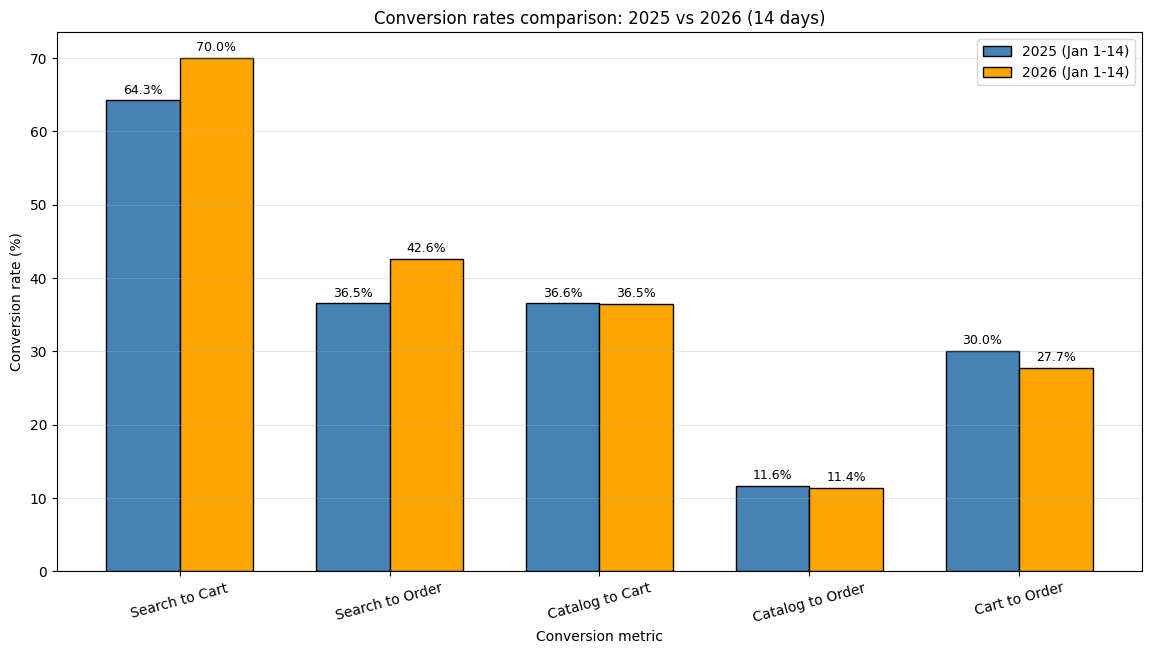

In [37]:
# CONVERSION COMPARISON 14-DAYS PERIODS (2025 VS 2026) CHARTS
metrics = ["Search to Cart", "Search to Order", "Catalog to Cart", "Catalog to Order", "Cart to Order"]
vals_2025 = [conv_2025[m] for m in metrics]
vals_2026 = [conv_2026[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize = (14, 7))

ax.bar(x - width/2, vals_2025, width, label = "2025 (Jan 1-14)", color = "steelblue", edgecolor = "black")
ax.bar(x + width/2, vals_2026, width, label = "2026 (Jan 1-14)", color = "orange", edgecolor = "black")

ax.set_xlabel("Conversion metric")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion rates comparison: 2025 vs 2026 (14 days)")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation = 15)
ax.legend()
ax.grid(alpha = 0.3, axis = "y")

for i, (v2025, v2026) in enumerate(zip(vals_2025, vals_2026)):
    ax.text(i - width/2, v2025 + 0.5, f"{v2025:.1f}%", ha = "center", va = "bottom", fontsize = 9)
    ax.text(i + width/2, v2026 + 0.5, f"{v2026:.1f}%", ha = "center", va = "bottom", fontsize = 9)

fig.savefig(REPORTS_CONV_FUNL_DIR / "18_conversion_comparison.png", dpi = 150)
plt.show()

### **Thoughts:**
- This 14-day period comparison (Jan 1-14) provides a clean, seasonally-adjusted view of platform efficiency without the "right-censoring" artifacts seen at the end of the dataset. The data confirms a strong structural shift in user behavior over the year;
- **Search** shows robust year-over-year improvement, with Search-to-Order conversion increasing by +6.08 p.p. (from 36.54% to 42.62%). This indicates significant enhancements in Ozon's search ranking algorithms and product card UX, converting "hot" intent into purchases more effectively;
- **Catalog** behavior remains fundamentally stagnant, with Catalog-to-Order dropping slightly by -0.22 p.p. (11.63% vs 11.41%). The widening gap between Search and Catalog confirms that Catalog traffic remains primarily "browsing" traffic with low purchase intent;
- The most concerning trend is the decline in **Cart-to-Order** conversion by -2.32 p.p. (from 30.04% to 27.73%). This suggests a degradation in the checkout funnel. Combined with our previous finding about the rise of the mass user segment in 2026, this drop likely reflects a "friction" point - new mass-market users who discover products through improved search are adding items to carts but experiencing friction at payment. This segment must be specifically accounted for during model calibration, as the 2025-trained model may overestimate their final conversion probability.

In [38]:
# Last 30 days: 2026-01-15 по 2026-02-13
last_30d_start = date(2026, 1, 15)
last_30d_end = date(2026, 2, 13)

user_last30d = (
    train_lf.filter(
        (pl.col("event_date") >= last_30d_start) &
        (pl.col("event_date") <= last_30d_end)
    )
    .group_by("user_id")
    .agg([
        pl.col("search").max().alias("had_search"),
        pl.col("cat").max().alias("had_cat"),
        pl.col("has_search_to_cart").max().alias("had_search_to_cart"),
        pl.col("has_search_to_ord").max().alias("had_search_to_ord"),
        pl.col("has_cat_to_cart").max().alias("had_cat_to_cart"),
        pl.col("has_cat_to_ord").max().alias("had_cat_to_ord"),
        (pl.col("to_cart") > 0).max().alias("had_any_cart"),
        (pl.col("to_ord") > 0).max().alias("had_any_order"),
    ])
    .collect()
)

# Counting the shares
total_users_30d = len(user_last30d)

funnel_30d = {
    "Total users (active in last 30d)": total_users_30d,
    "Used search": user_last30d["had_search"].sum(),
    "Used catalog": user_last30d["had_cat"].sum(),
    "Search to Cart": user_last30d["had_search_to_cart"].sum(),
    "Search to Order": user_last30d["had_search_to_ord"].sum(),
    "Catalog to Cart": user_last30d["had_cat_to_cart"].sum(),
    "Catalog to Order": user_last30d["had_cat_to_ord"].sum(),
    "Added to cart (any channel)": user_last30d["had_any_cart"].sum(),
    "Ordered (any channel)": user_last30d["had_any_order"].sum(),
}

print("FUNNEL ANALYSIS (Last 30 days: 2026-01-15 to 2026-02-13)")

for stage, count in funnel_30d.items():
    pct = count / total_users_30d * 100
    print(f"{stage:40} {count:8,} ({pct:5.1f}%)")

print("\nConversion rates (Last 30d):")

search_users_30d = user_last30d["had_search"].sum()
cat_users_30d = user_last30d["had_cat"].sum()
cart_users_30d = user_last30d["had_any_cart"].sum()

print(f"Search to Cart: {user_last30d['had_search_to_cart'].sum() / search_users_30d * 100:.2f}%")
print(f"Search to Order: {user_last30d['had_search_to_ord'].sum() / search_users_30d * 100:.2f}%")
print(f"Catalog to Cart: {user_last30d['had_cat_to_cart'].sum() / cat_users_30d * 100:.2f}%")
print(f"Catalog to Order: {user_last30d['had_cat_to_ord'].sum() / cat_users_30d * 100:.2f}%")
print(f"Cart to Order: {user_last30d['had_any_order'].sum() / cart_users_30d * 100:.2f}%")

FUNNEL ANALYSIS (Last 30 days: 2026-01-15 to 2026-02-13)
Total users (active in last 30d)          250,000 (100.0%)
Used search                               241,831 ( 96.7%)
Used catalog                              125,768 ( 50.3%)
Search to Cart                            192,098 ( 76.8%)
Search to Order                           131,986 ( 52.8%)
Catalog to Cart                            54,157 ( 21.7%)
Catalog to Order                           19,157 (  7.7%)
Added to cart (any channel)               196,193 ( 78.5%)
Ordered (any channel)                     135,165 ( 54.1%)

Conversion rates (Last 30d):
Search to Cart: 79.43%
Search to Order: 54.58%
Catalog to Cart: 43.06%
Catalog to Order: 15.23%
Cart to Order: 68.89%


In [39]:
# Creating a comparison table
comparison_data = {
    "Metric": [
        "Search to Cart",
        "Search to Order",
        "Catalog to Cart",
        "Catalog to Order",
        "Cart to Order",
    ],
    "Ever (13 months)": [
        user_funnel["ever_search_to_cart"].sum() / user_funnel["ever_search"].sum() * 100,
        user_funnel["ever_search_to_ord"].sum() / user_funnel["ever_search"].sum() * 100,
        user_funnel["ever_cat_to_cart"].sum() / user_funnel["ever_cat"].sum() * 100,
        user_funnel["ever_cat_to_ord"].sum() / user_funnel["ever_cat"].sum() * 100,
        user_funnel["ever_any_order"].sum() / user_funnel["ever_any_cart"].sum() * 100,
    ],
    "Last 30d": [
        user_last30d["had_search_to_cart"].sum() / user_last30d["had_search"].sum() * 100,
        user_last30d["had_search_to_ord"].sum() / user_last30d["had_search"].sum() * 100,
        user_last30d["had_cat_to_cart"].sum() / user_last30d["had_cat"].sum() * 100,
        user_last30d["had_cat_to_ord"].sum() / user_last30d["had_cat"].sum() * 100,
        user_last30d["had_any_order"].sum() / user_last30d["had_any_cart"].sum() * 100,
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df["Difference"] = comparison_df["Last 30d"] - comparison_df["Ever (13 months)"]

print("FUNNEL COMPARISON: Ever vs Last 30 days")
print(comparison_df.to_string(index = False))

FUNNEL COMPARISON: Ever vs Last 30 days
          Metric  Ever (13 months)  Last 30d  Difference
  Search to Cart         98.259925 79.434812  -18.825113
 Search to Order         87.295568 54.577784  -32.717785
 Catalog to Cart         73.321358 43.061033  -30.260325
Catalog to Order         42.690038 15.232015  -27.458024
   Cart to Order         89.070234 68.893895  -20.176339


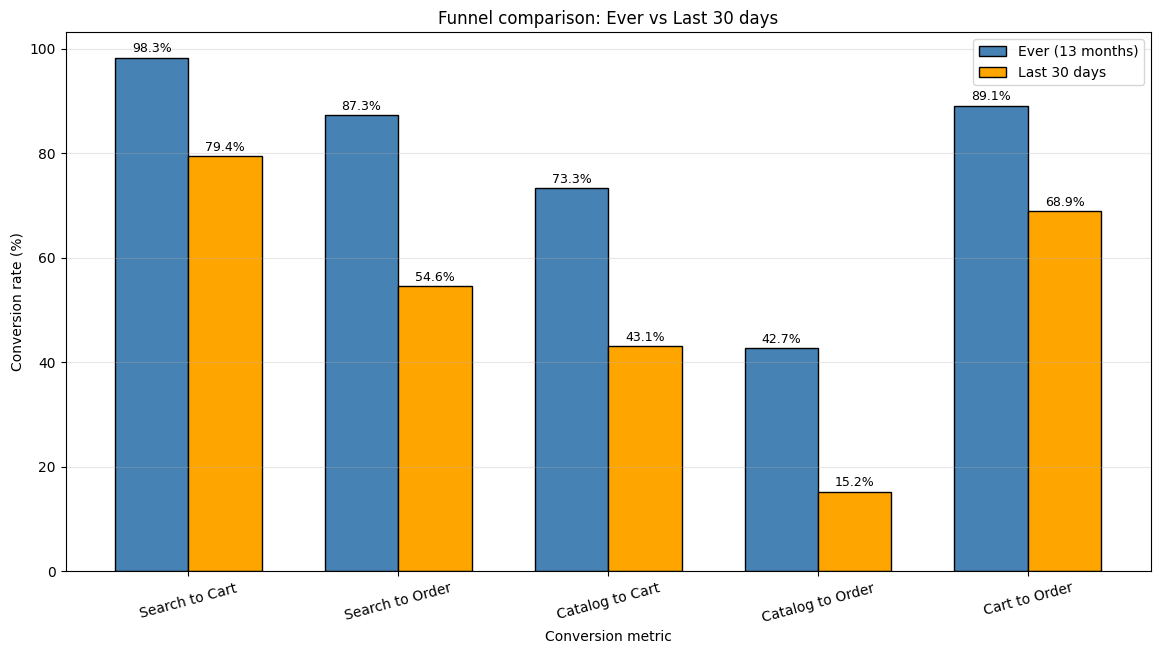

In [40]:
# Visualization
metrics = comparison_df["Metric"].tolist()
ever_vals = comparison_df["Ever (13 months)"].tolist()
last30d_vals = comparison_df["Last 30d"].tolist()

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize = (14, 7))

ax.bar(x - width/2, ever_vals, width, label = "Ever (13 months)", color = "steelblue", edgecolor = "black")
ax.bar(x + width/2, last30d_vals, width, label = "Last 30 days", color = "orange", edgecolor = "black")

ax.set_xlabel("Conversion metric")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Funnel comparison: Ever vs Last 30 days")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation = 15)
ax.legend()
ax.grid(alpha = 0.3, axis = "y")

for i, (ever, last30d) in enumerate(zip(ever_vals, last30d_vals)):
    ax.text(i - width/2, ever + 0.5, f"{ever:.1f}%", ha = "center", va = "bottom", fontsize = 9)
    ax.text(i + width/2, last30d + 0.5, f"{last30d:.1f}%", ha = "center", va = "bottom", fontsize = 9)

fig.savefig(REPORTS_CONV_FUNL_DIR / "19_funnel_ever_vs_last30d.png", dpi = 150)
plt.show()

### **Thoughts:**
- We can see the cart stability (Cart to Order): Although `Cart to Order` dropped by 20 p. p. (from 89.1% to 68.9%), 68.9% is still a very high conversion rate for the payment stage. This means that if a user has already added something to the cart, the likelihood of a purchase remains high, even if they have been abandoning the cart slightly more often in the last 30 days.

## **03 - GMV DECOMPOSITION**

In [41]:
# THE BASIC DECOMPOSITION IN HISTORY
# For each user, we calculate: whether they made a purchase, how many orders they placed, GMV, AOV
user_gmv_decomp = (
    train_lf.group_by("user_id")
    .agg([
        (pl.col("to_ord") > 0).max().alias("ever_ordered"),
        pl.col("to_ord").sum().alias("total_orders"),
        pl.col("gmv").sum().alias("total_gmv"),
    ])
    .with_columns([
        # AOV only for those who ordered
        pl.when(pl.col("ever_ordered"))
          .then(pl.col("total_gmv") / pl.col("total_orders"))
          .otherwise(None)
          .alias("aov"),
    ])
    .collect()
)

buyers = user_gmv_decomp.filter(pl.col("ever_ordered"))

p_buy = len(buyers) / len(user_gmv_decomp)
orders_per_buyer = buyers["total_orders"].mean()
aov = buyers["aov"].mean()
gmv_per_user = user_gmv_decomp["total_gmv"].mean()

print("GMV DECOMPOSITION (entire period, 13 months)")
print(f"Total users: {len(user_gmv_decomp):,}")
print(f"Buyers: {len(buyers):,}")
print(f"\nP(buy):           {p_buy:.4f} ({p_buy*100:.2f}%)")
print(f"Orders per buyer: {orders_per_buyer:.2f}")
print(f"AOV (avg order):  {aov:.2f} RUB\n")
print(f"Check: P(buy) * Orders/buyer * AOV = {p_buy * orders_per_buyer * aov:.2f}")
print(f"Actual GMV per user:                  {gmv_per_user:.2f}")

GMV DECOMPOSITION (entire period, 13 months)
Total users: 250,000
Buyers: 219,168

P(buy):           0.8767 (87.67%)
Orders per buyer: 36.74
AOV (avg order):  37.99 RUB

Check: P(buy) * Orders/buyer * AOV = 1223.48
Actual GMV per user:                  1088.41


In [42]:
# DECOMPOSITION BY HISTORICAL GMV BINS
# Taking historical GMV (up to AS_OF), which has already been calculated in historical_gmv
# Adding order data and AOV for the entire history
user_gmv_with_bins = (
    user_gmv_decomp
    .join(historical_gmv.select(["user_id", "gmv_bin"]), on = "user_id", how = "left")
)

# Aggregating by bins
bin_stats = (
    user_gmv_with_bins
    .group_by("gmv_bin")
    .agg([
        pl.len().alias("n_users"),
        pl.col("ever_ordered").mean().alias("p_buy"),
        pl.col("total_orders").filter(pl.col("ever_ordered")).mean().alias("orders_per_buyer"),
        pl.col("aov").filter(pl.col("ever_ordered")).mean().alias("aov"),
        pl.col("total_gmv").sum().alias("total_bin_gmv"),
    ])
    .sort("gmv_bin")
)

BIN_ORDER = ["0-1%", "1-5%", "5-10%", "10-20%", "20-50%", "50-100%"]
bin_stats_pd = bin_stats.to_pandas()
bin_stats_pd["gmv_bin"] = pd.Categorical(bin_stats_pd["gmv_bin"], categories = BIN_ORDER, ordered = True)
bin_stats_pd = bin_stats_pd.sort_values("gmv_bin")

print("GMV DECOMPOSITION BY HISTORICAL GMV BIN")
print(bin_stats_pd.to_string(index = False))

GMV DECOMPOSITION BY HISTORICAL GMV BIN
gmv_bin  n_users    p_buy  orders_per_buyer        aov  total_bin_gmv
   0-1%     2500 1.000000        328.726400 108.258577   4.045494e+07
   1-5%    10000 1.000000        154.699900  61.669061   6.063446e+07
  5-10%    12500 1.000000         95.884000  53.768884   4.258133e+07
 10-20%    25000 1.000000         62.279320  48.935100   5.116587e+07
 20-50%    75000 1.000000         29.809427  40.906429   6.265528e+07
50-100%   125000 0.753344          7.347645  26.280163   1.460969e+07


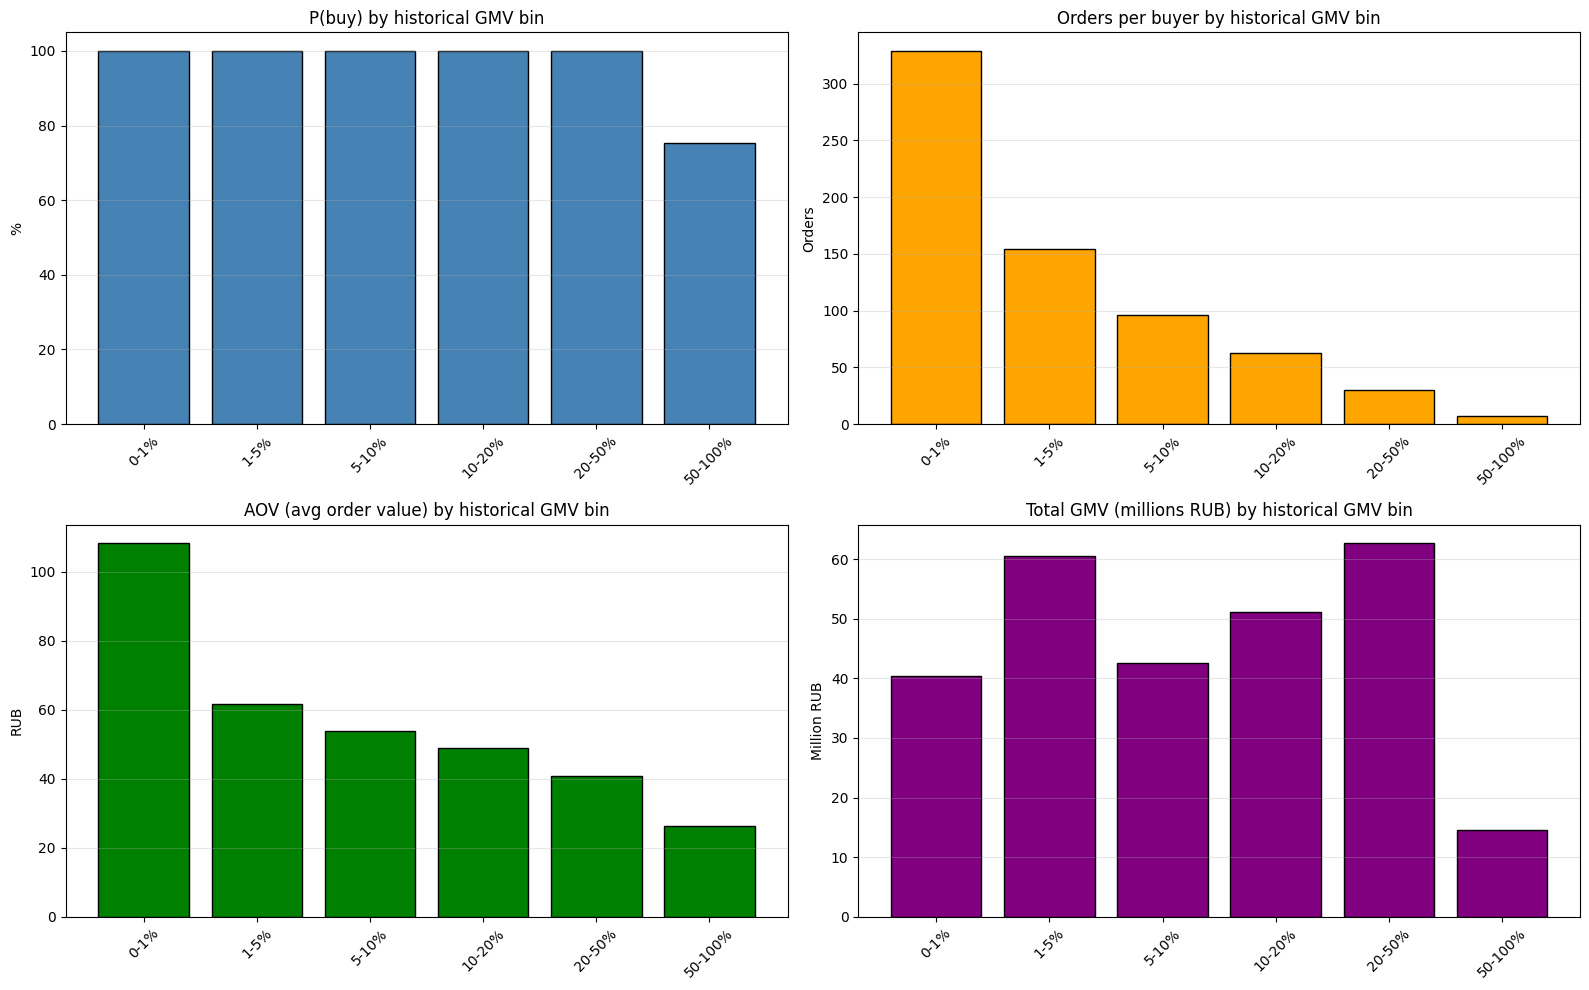

In [43]:
# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# P(buy) by bins
axes[0, 0].bar(bin_stats_pd["gmv_bin"], bin_stats_pd["p_buy"] * 100, 
               color = "steelblue", edgecolor = "black")
axes[0, 0].set_title("P(buy) by historical GMV bin")
axes[0, 0].set_ylabel("%")
axes[0, 0].tick_params(axis = "x", rotation = 45)
axes[0, 0].grid(alpha = 0.3, axis = "y")

# Orders per buyer
axes[0, 1].bar(bin_stats_pd["gmv_bin"], bin_stats_pd["orders_per_buyer"], 
               color = "orange", edgecolor = "black")
axes[0, 1].set_title("Orders per buyer by historical GMV bin")
axes[0, 1].set_ylabel("Orders")
axes[0, 1].tick_params(axis = "x", rotation = 45)
axes[0, 1].grid(alpha = 0.3, axis = "y")

# AOV
axes[1, 0].bar(bin_stats_pd["gmv_bin"], bin_stats_pd["aov"], 
               color = "green", edgecolor = "black")
axes[1, 0].set_title("AOV (avg order value) by historical GMV bin")
axes[1, 0].set_ylabel("RUB")
axes[1, 0].tick_params(axis = "x", rotation = 45)
axes[1, 0].grid(alpha = 0.3, axis = "y")

# Total GMV by bin
axes[1, 1].bar(bin_stats_pd["gmv_bin"], bin_stats_pd["total_bin_gmv"] / 1e6, 
               color = "purple", edgecolor = "black")
axes[1, 1].set_title("Total GMV (millions RUB) by historical GMV bin")
axes[1, 1].set_ylabel("Million RUB")
axes[1, 1].tick_params(axis = "x", rotation = 45)
axes[1, 1].grid(alpha = 0.3, axis = "y")

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "20_gmv_decomposition_by_bin.png", dpi = 150)
plt.show()

### Thoughts:
- Our previous understanding of the structural user divide is fully confirmed upon decomposing the full 13-month GMV by historical `gmv_bin`. The behavioral gap between the top-tier elite and the mass segment is stark. The top 1% (2,500 users) exhibit a distinct buying pattern with an **AOV of 108.26 RUB** and an exceptional frequency of **328.73 orders per buyer**, whereas the mass segment (50-100%, 125,000 users) drops to an **AOV of 26.28 RUB** and only **7.35 orders per buyer**. The overall platform indicators (36.74 orders per buyer and 37.99 RUB AOV) are heavily skewed by the top segments;

- As we look closely at the `p_buy` and frequency metrics, we confirm that users in the historical 0-1% down to 20-50% bins have a perfect **p_buy = 1.000**, meaning they almost always convert during the period. However, the 50-100% mass segment shows a sharp drop in both intent and frequency, with a **p_buy of 0.753** and orders plummeting from 29.81 (in 20-50%) to just 7.35. This suggests that the bottom half of users are highly sensitive to purchase triggers and checkout friction, making them a challenging cohort for monetization;

- The crucial insight lies in the `Total GMV` breakdown. Contrary to the common belief that revenue heavily relies exclusively on the top 1%, the real economic engine of the platform is split between two distinct anchors: the **1-5% bin (10,000 users) generating 60.63M RUB**, and the **20-50% bin (75,000 users) generating 62.66M RUB**, which together account for nearly half of the platform's 272M RUB total GMV. Meanwhile, the vast mass segment (50-100%) contributes only **14.61M RUB**. It acts as an "opportunity zone" for upscaling rather than a current revenue anchor;

- Since this moment, we can shift our feature engineering and validation strategy. The `gmv_bin` must be treated as a critical categorical feature for the ML model, as the average behavior drastically shifts between bins (AOV varies by a factor of 4x between extremes). Furthermore, when validating the model, we must apply stratified metrics specifically focusing on the **1-5%** and **20-50%** bins - since they cumulatively hold the largest share of total revenue, an error in predictions for these groups will disproportionately impact the overall forecasted GMV;

- *Minor note:* The computed check `P(buy) * Orders/buyer * AOV = 1223.48 RUB` slightly overshoots the actual `GMV per user = 1088.41 RUB`. It's okay, because of Jensen's inequality for products of random variables. The mean of the product does not equal the product of the means when the variables are correlated.

In [44]:
# DECOMPOSITION OF P(BUY) * ORDERS * AOV BY BINS
bin_stats_pd = bin_stats_pd.copy()
bin_stats_pd["predicted_gmv_per_user"] = (
    bin_stats_pd["p_buy"] * bin_stats_pd["orders_per_buyer"] * bin_stats_pd["aov"]
)

# Which component differs more from the population average?
pop_p_buy = p_buy
pop_orders = orders_per_buyer
pop_aov = aov

bin_stats_pd["p_buy_ratio"] = bin_stats_pd["p_buy"] / pop_p_buy
bin_stats_pd["orders_ratio"] = bin_stats_pd["orders_per_buyer"] / pop_orders
bin_stats_pd["aov_ratio"] = bin_stats_pd["aov"] / pop_aov

print("RELATIVE CONTRIBUTION OF EACH COMPONENT (vs population mean)")
print("Values > 1 mean higher than average")
print(bin_stats_pd[["gmv_bin", "p_buy_ratio", "orders_ratio", "aov_ratio"]].to_string(index = False))

RELATIVE CONTRIBUTION OF EACH COMPONENT (vs population mean)
Values > 1 mean higher than average
gmv_bin  p_buy_ratio  orders_ratio  aov_ratio
   0-1%     1.140677      8.947664   2.849877
   1-5%     1.140677      4.210805   1.623421
  5-10%     1.140677      2.609884   1.415451
 10-20%     1.140677      1.695192   1.288203
 20-50%     1.140677      0.811388   1.076850
50-100%     0.859323      0.199997   0.691818


## **04 - CHANNEL INTERSECTION**

In [45]:
# CHANNEL INTERSECTION
# For each user, determine which channels they used
user_channels = (
    train_lf.group_by("user_id")
    .agg([
        pl.col("search").max().alias("used_search"),
        pl.col("cat").max().alias("used_cat"),
        pl.col("gmv_search").sum().alias("gmv_search_total"),
        pl.col("gmv_cat").sum().alias("gmv_cat_total"),
        pl.col("gmv").sum().alias("gmv_total"),
        pl.col("to_ord").sum().alias("total_orders"),
    ])
    .with_columns([
      pl.when((pl.col("used_search") > 0) & (pl.col("used_cat") > 0))
          .then(pl.lit("Both"))
          .when(pl.col("used_search") > 0)
          .then(pl.lit("Search only"))
          .when(pl.col("used_cat") > 0)
          .then(pl.lit("Catalog only"))
          .otherwise(pl.lit("Neither"))
          .alias("channel_type"),
    ])
    .collect()
)

# Statistics by type
channel_stats = (
    user_channels.group_by("channel_type")
    .agg([
        pl.len().alias("n_users"),
        pl.col("gmv_total").sum().alias("total_gmv"),
        pl.col("gmv_total").mean().alias("avg_gmv"),
        pl.col("total_orders").sum().alias("total_orders"),
        pl.col("total_orders").filter(pl.col("total_orders") > 0).mean().alias("orders_per_buyer"),
    ])
    .sort("total_gmv", descending = True)
)

print("CHANNEL INTERSECTION ANALYSIS")
print(channel_stats)

CHANNEL INTERSECTION ANALYSIS
shape: (4, 6)
┌──────────────┬─────────┬──────────────┬─────────────┬──────────────┬──────────────────┐
│ channel_type ┆ n_users ┆ total_gmv    ┆ avg_gmv     ┆ total_orders ┆ orders_per_buyer │
│ ---          ┆ ---     ┆ ---          ┆ ---         ┆ ---          ┆ ---              │
│ str          ┆ u32     ┆ f64          ┆ f64         ┆ i64          ┆ f64              │
╞══════════════╪═════════╪══════════════╪═════════════╪══════════════╪══════════════════╡
│ Both         ┆ 232562  ┆ 2.6888e8     ┆ 1156.173075 ┆ 7962726      ┆ 38.12215         │
│ Search only  ┆ 16910   ┆ 3.1954e6     ┆ 188.964818  ┆ 88384        ┆ 8.630407         │
│ Catalog only ┆ 141     ┆ 24178.214841 ┆ 171.476701  ┆ 856          ┆ 16.784314        │
│ Neither      ┆ 387     ┆ 77.991213    ┆ 0.201528    ┆ 2            ┆ 1.0              │
└──────────────┴─────────┴──────────────┴─────────────┴──────────────┴──────────────────┘


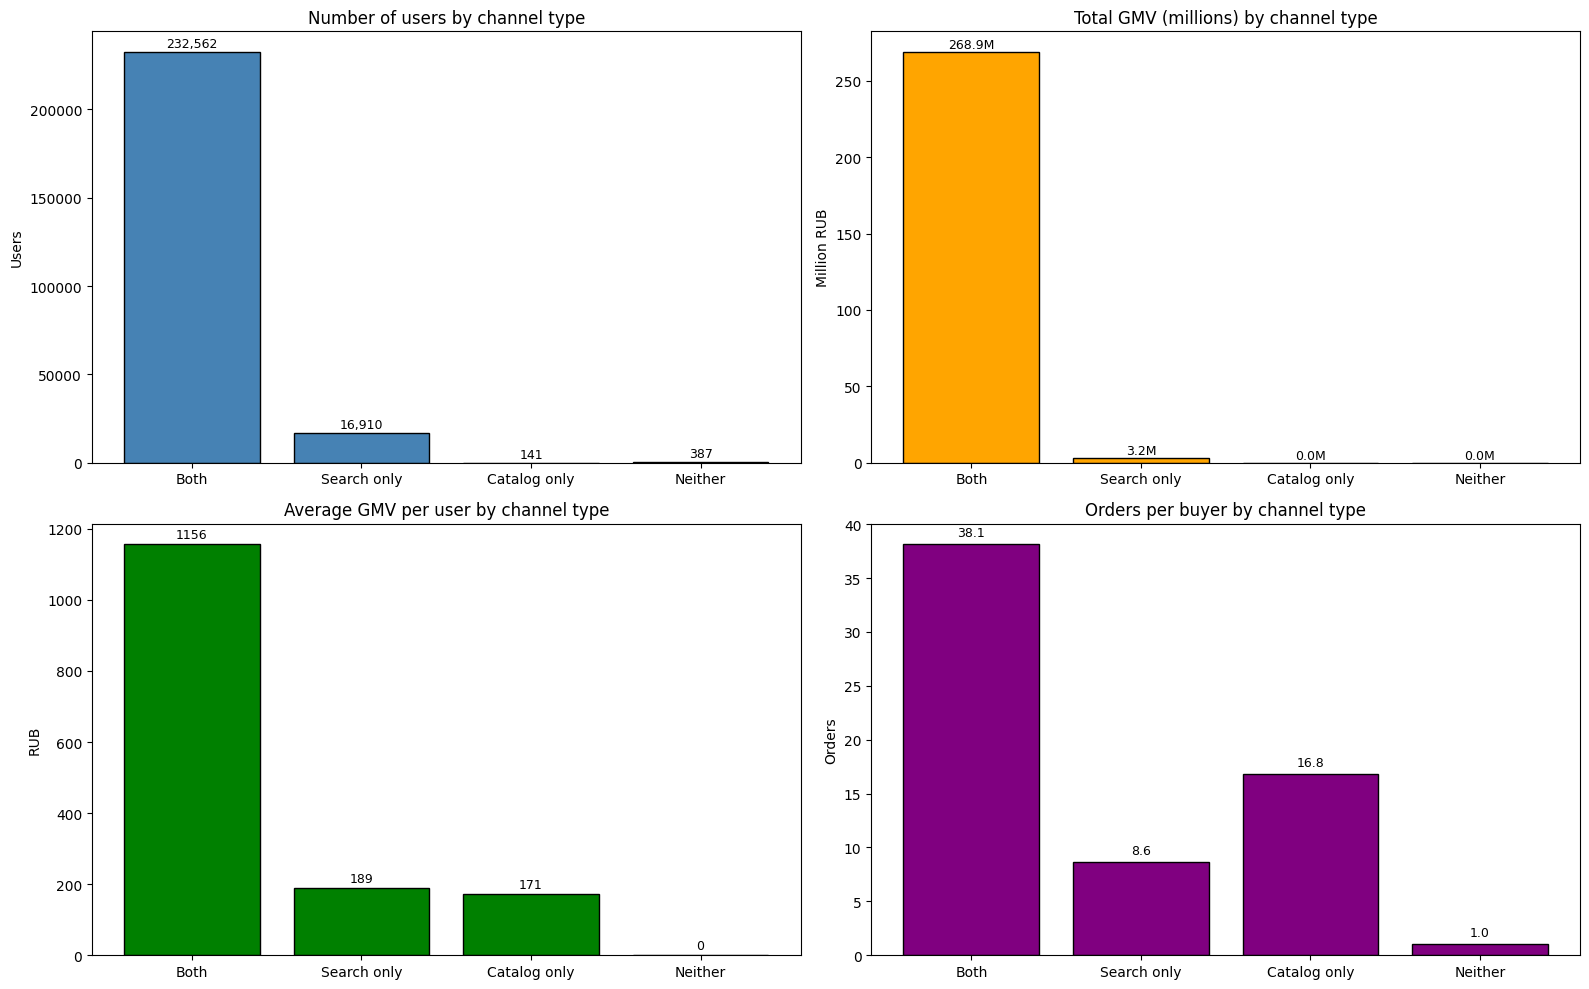

In [46]:
# VISUALIZATION
channel_pd = channel_stats.to_pandas()

fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Number of users
axes[0, 0].bar(channel_pd["channel_type"], channel_pd["n_users"],
               color = "steelblue", edgecolor = "black")
axes[0, 0].set_title("Number of users by channel type")
axes[0, 0].set_ylabel("Users")
for i, (ct, n) in enumerate(zip(channel_pd["channel_type"], channel_pd["n_users"])):
    axes[0, 0].text(i, n + 1000, f"{n:,}", ha = "center", va = "bottom", fontsize = 9)

# Total GMV
axes[0, 1].bar(channel_pd["channel_type"], channel_pd["total_gmv"] / 1e6,
               color = "orange", edgecolor = "black")
axes[0, 1].set_title("Total GMV (millions) by channel type")
axes[0, 1].set_ylabel("Million RUB")
for i, (ct, gmv) in enumerate(zip(channel_pd["channel_type"], channel_pd["total_gmv"])):
    axes[0, 1].text(i, gmv/1e6 + 0.5, f"{gmv/1e6:.1f}M", ha = "center", va = "bottom", fontsize = 9)

# Average GMV per user
axes[1, 0].bar(channel_pd["channel_type"], channel_pd["avg_gmv"],
               color = "green", edgecolor = "black")
axes[1, 0].set_title("Average GMV per user by channel type")
axes[1, 0].set_ylabel("RUB")
for i, (ct, avg) in enumerate(zip(channel_pd["channel_type"], channel_pd["avg_gmv"])):
    axes[1, 0].text(i, avg + 10, f"{avg:.0f}", ha = "center", va = "bottom", fontsize = 9)

# Orders per buyer
axes[1, 1].bar(channel_pd["channel_type"], channel_pd["orders_per_buyer"],
               color = "purple", edgecolor = "black")
axes[1, 1].set_title("Orders per buyer by channel type")
axes[1, 1].set_ylabel("Orders")
for i, (ct, orders) in enumerate(zip(channel_pd["channel_type"], channel_pd["orders_per_buyer"])):
    axes[1, 1].text(i, orders + 0.5, f"{orders:.1f}", ha = "center", va = "bottom", fontsize = 9)

plt.tight_layout()
fig.savefig(REPORTS_GMV_DIR / "21_channel_intersection.png", dpi = 150)
plt.show()

### Thoughts:
- The Channel Intersection Analysis provides the ultimate proof that Search and Catalog are not interchangeable paths, but rather **synergistic pillars** of the user journey. The data paints a clear picture: users who utilize both channels (`Both`) are in a fundamentally different monetization league compared to single-channel users;

- Looking closely at the metrics, `Both` users account for **approximately 93% of all users (232,562)**, but generate **near 268.9M RUB (over 98% of total GMV)**. Their average spend is **1,156 RUB** with **38.1 orders per buyer**. In contrast, `Search only` users spend just **189 RUB** on average and make only **8.6 orders**. The difference is staggering - multi-channel usage multiplies average GMV by a factor of 6x and order frequency by 4x;

- The `Catalog only` group is essentially an **insignificant statistical noise**. With only **141 users** and an average GMV of **171 RUB**, these users are likely a tiny fraction of visitors coming via direct category links. It solidifies the finding that Catalog as a standalone channel is almost entirely non-viable for generating substantial revenue without being complemented by Search. Interestingly, `Catalog only` users have an order frequency of **16.8**, which is roughly 2x higher than `Search only` (8.6), implying they might be low-spenders but loyal to specific niches;

- A crucial behavioral hypothesis emerges: **"Search only" users are low-intent or ultra-specific**. They arrive knowing exactly what they want and leave immediately after a single purchase, without discovering other products via the catalog. "Both" users, on the other hand, likely use Search to find a target item, then navigate the Catalog to explore related or complementary products, leading to much larger baskets and repeat purchases;

- **For our ML model, this creates a critical categorical feature**: the *channel behavior type (before `AS_OF`)*. If a user historically belongs to `Search only`, the model must strongly penalize its GMV prediction, expecting 189 RUB at maximum. If a user belongs to `Both`, the model should be aggressively rewarded, expecting a much higher baseline GMV (about 1,156 RUB). Over-predicting for `Search only` users will directly misalign the revenue forecast. Feature engineering must account for this intersection!